In [1]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter


In [3]:
input_tif = "/isipd/projects/p_planetdw/data/lidar/05_results/Perma-X-2025-Till/DSM/WC_Inuvik_20230705_15cm_01_DSM.tif"
output_tif = "/isipd/projects/p_planetdw/data/lidar/05_results/Perma-X-2025-Till/DSM/Inuvik_DSM_2025_2m.tif"

target_resolution = 2  # metres

with rasterio.open(input_tif) as src:

    # Original resolution
    original_res_x = src.res[0]
    original_res_y = src.res[1]

    # Compute new dimensions
    scale_x = original_res_x / target_resolution
    scale_y = abs(original_res_y) / target_resolution

    new_width = int(src.width * scale_x)
    new_height = int(src.height * scale_y)

    # Resample
    data = src.read(
        out_shape=(
            src.count,
            new_height,
            new_width
        ),
        resampling=Resampling.average
    )

    # New transform
    new_transform = rasterio.Affine(
        target_resolution,
        src.transform.b,
        src.transform.c,
        src.transform.d,
        -target_resolution,
        src.transform.f
    )

    # Output profile
    profile = src.profile.copy()

    profile.update({
        "height": new_height,
        "width": new_width,
        "transform": new_transform,
        "compress": "lzw",
        "tiled": True,
        "blockxsize": 256,
        "blockysize": 256,
        "dtype": data.dtype
    })

    with rasterio.open(output_tif, "w", **profile) as dst:
        dst.write(data)

print("Done.")

Done.


In [1]:
macs= "/isipd/projects/Response/GIS_RS_projects/Masterarbeit_Till_Weiss/results/DoD/Inuvik_Macs/DSM/Inuvik_Macs_dDSM_simple.tif"
lidar = "/isipd/projects/Response/GIS_RS_projects/Masterarbeit_Till_Weiss/results/DoD/Inuvik_Carl/DSM/Inuvik_Carl_dDSM_simple.tif"

output_path = "/isipd/projects/Response/GIS_RS_projects/Masterarbeit_Till_Weiss/outputs/plots/MacsVsLidar/"

In [99]:
with rasterio.open(macs) as src1:
    print("Macs")
    print("CRS:", src1.crs)
    print("Resolution:", src1.res)
    print("Bounds:", src1.bounds)
    print("Shape:", src1.shape)

with rasterio.open(lidar) as src2:
    print("\nLidar")
    print("CRS:", src2.crs)
    print("Resolution:", src2.res)
    print("Bounds:", src2.bounds)
    print("Shape:", src2.shape)

Macs
CRS: EPSG:32608
Resolution: (2.000222024866785, 2.0)
Bounds: BoundingBox(left=547921.98328, bottom=7578438.004500001, right=556930.98328, top=7588938.004500001)
Shape: (5250, 4504)

Lidar
CRS: EPSG:32608
Resolution: (2.0, 2.0)
Bounds: BoundingBox(left=547922.56, bottom=7578364.59, right=556930.56, top=7588938.59)
Shape: (5287, 4504)


In [100]:
with rasterio.open(macs) as src:
    print(src.nodata)

with rasterio.open(lidar) as src:
    print(src.nodata)

-32768.0
-9999.0


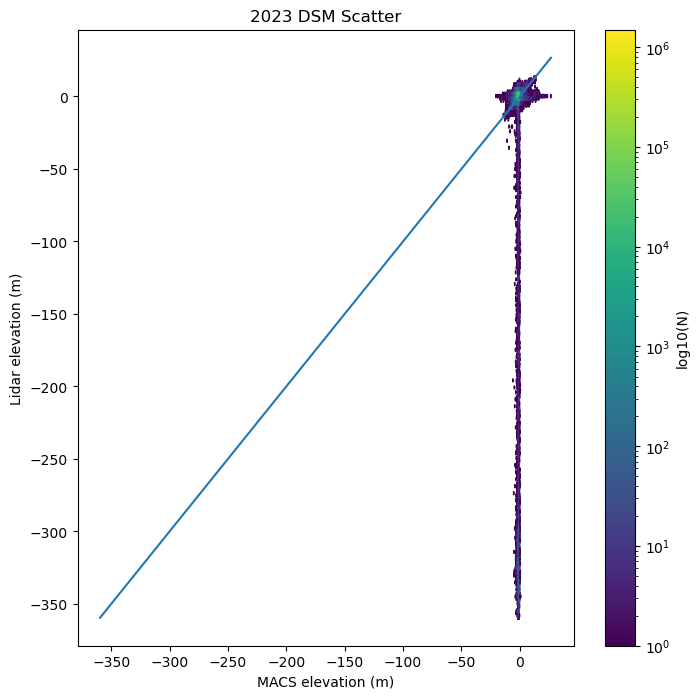

In [ ]:
# Reference DSM
with rasterio.open(macs) as ref:
    dsm1 = ref.read(1)
    ref_transform = ref.transform
    ref_crs = ref.crs
    ref_shape = dsm1.shape

# DSM to align
with rasterio.open(lidar) as src:

    nodata = src.nodata

    dsm2_resampled = np.full(ref_shape, np.nan, dtype=np.float32)

    reproject(
        source=rasterio.band(src, 1),
        destination=dsm2_resampled,
        src_transform=src.transform,
        src_crs=src.crs,
        src_nodata=nodata,
        dst_transform=ref_transform,
        dst_crs=ref_crs,
        dst_nodata=np.nan,
        resampling=Resampling.bilinear
    )

# Create mask
mask = (
    np.isfinite(dsm1) &
    np.isfinite(dsm2_resampled) &
    (dsm1 != -32768) &
    (dsm2_resampled != -9999) 

)

x = dsm1[mask]
y = dsm2_resampled[mask]

# Plot
plt.figure(figsize=(8,8))

plt.hexbin(x, y, gridsize=200, bins='log')

minval = min(x.min(), y.min())
maxval = max(x.max(), y.max())

plt.plot([minval, maxval], [minval, maxval])

plt.xlabel("MACS elevation (m)")
plt.ylabel("Lidar elevation (m)")
plt.title("2023 DSM Scatter")
plt.colorbar(label="log10(N)")

#plt.savefig(f"{output_path}2023_DSM_scatter_ICP_c1.png", dpi=300)

plt.show()


In [102]:
print(np.nanmin(x), np.nanmax(x))
print(np.nanmin(y), np.nanmax(y))

-20.414444 26.684942
-359.496 13.180888


In [111]:
# Difference
ddsm = dsm2_resampled - dsm1

# Optional: mask extreme artefacts
#ddsm = np.where(
#    np.abs(ddsm) > 20,
#    np.nan,
#    ddsm
#)

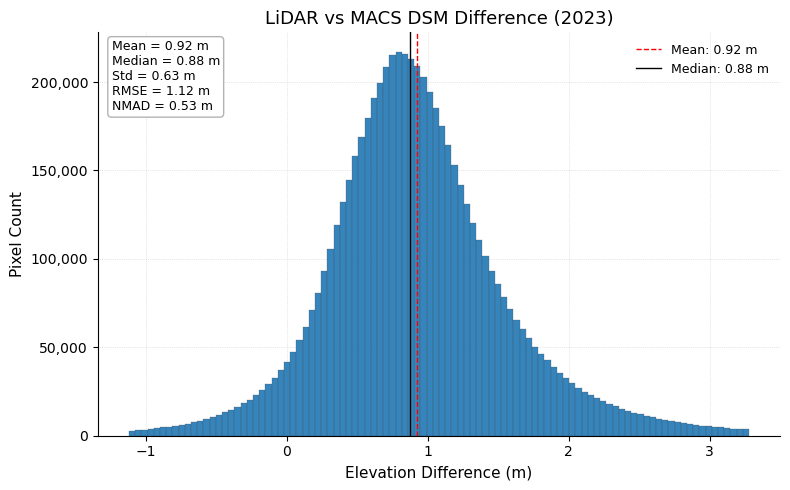

In [106]:
# -----------------------------------------
# DATA
# -----------------------------------------

vals = ddsm.flatten()   # replace with your array
vals = vals[np.isfinite(vals)]

# Optional clipping to remove extreme outliers
p1, p99 = np.percentile(vals, [1, 99])
vals = vals[(vals >= p1) & (vals <= p99)]

# -----------------------------------------
# STATISTICS
# -----------------------------------------

mean = np.mean(vals)
median = np.median(vals)
std = np.std(vals)
rmse = np.sqrt(np.mean(vals**2))
nmad = 1.4826 * np.median(np.abs(vals - median))

# -----------------------------------------
# FIGURE
# -----------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    vals,
    bins=100,
    linewidth=0.2,
    alpha=0.9,
    edgecolor='0.3'
)

# Mean and median lines
ax.axvline(mean, linestyle='--', color = 'red', linewidth=1, label=f'Mean: {mean:.2f} m')
ax.axvline(median, linestyle='-', color = 'k', linewidth=1, label=f'Median: {median:.2f} m')

# Labels
ax.set_title('LiDAR vs MACS DSM Difference (2023)', fontsize=13)
ax.set_xlabel('Elevation Difference (m)', fontsize=11)
ax.set_ylabel('Pixel Count', fontsize=11)

# Grid
ax.grid(True, linestyle=':', linewidth=0.5, alpha=0.6)
ax.set_axisbelow(True)

# Clean axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Tick formatting
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{int(x):,}')
)

# Statistics box
stats = (
    f'Mean = {mean:.2f} m\n'
    f'Median = {median:.2f} m\n'
    f'Std = {std:.2f} m\n'
    f'RMSE = {rmse:.2f} m\n'
    f'NMAD = {nmad:.2f} m'
)

ax.text(
    0.02,
    0.98,
    stats,
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='top',
    bbox=dict(
        facecolor='white',
        edgecolor='0.7',
        boxstyle='round'
    )
)

ax.legend(fontsize=9, frameon=False)

plt.tight_layout()

# Optional export
#plt.savefig(f"{output_path}/2023_DSM_difference_histogram_ICP_c1.png", dpi=300)

plt.show()

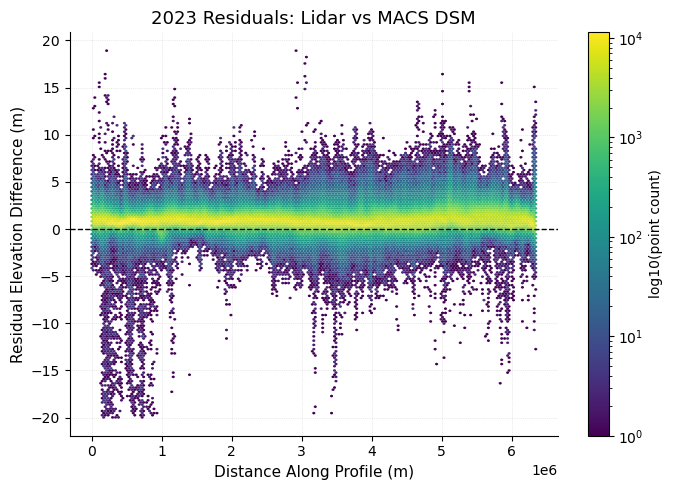

In [122]:
# Flatten for plotting
diff = ddsm.flatten()
diff = diff[np.isfinite(diff)]

# Example x values
# Replace with your actual distance/profile variable
x = np.arange(len(diff))

fig, ax = plt.subplots(figsize=(7, 5))

hb = ax.hexbin(
    x,
    diff,
    gridsize=150,
    bins='log',
    mincnt=1,
    linewidths=0
)

# Zero residual reference
ax.axhline(
    0,
    linestyle='--',
    linewidth=1,
    color='black'
)

# Labels
ax.set_xlabel('Distance Along Profile (m)', fontsize=11)
ax.set_ylabel('Residual Elevation Difference (m)', fontsize=11)

# Title
ax.set_title('2023 Residuals: Lidar vs MACS DSM', fontsize=13)

# Optional y-limits
# ax.set_ylim(-5, 5)

# Light grid
ax.grid(
    True,
    linestyle=':',
    linewidth=0.5,
    alpha=0.5
)

ax.set_axisbelow(True)

# Cleaner axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Colourbar
cbar = fig.colorbar(hb, ax=ax)
cbar.set_label('log10(point count)', fontsize=10)

# Tick size
ax.tick_params(axis='both', labelsize=10)

#plt.savefig(f"{output_path}2023_DSM_residuals_ICP_c1.png", dpi=300)

plt.tight_layout()
plt.show()

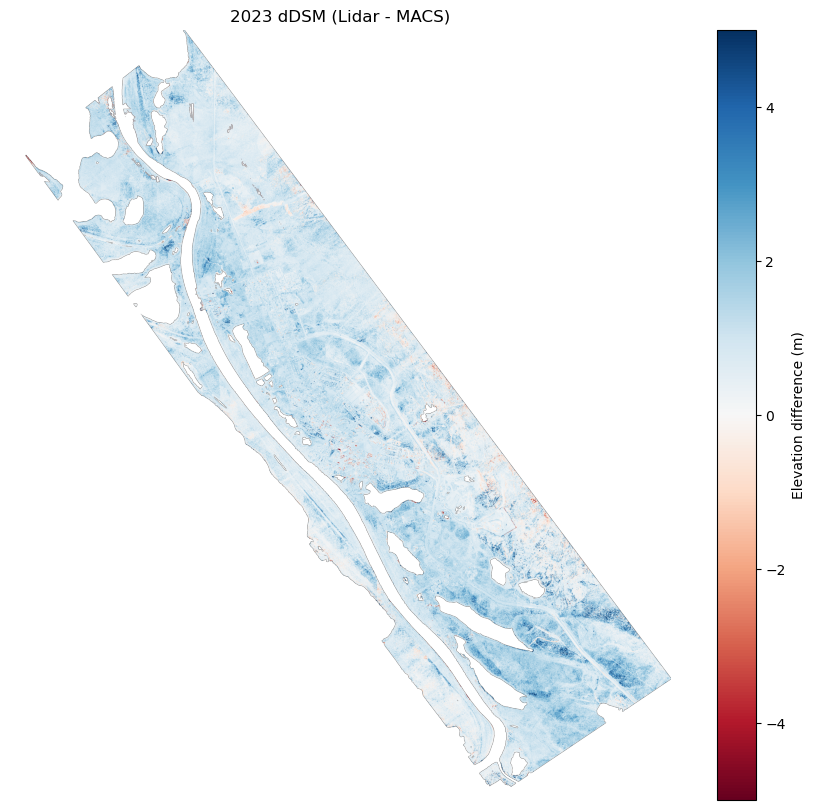

In [123]:
plt.figure(figsize=(12,10))

im = plt.imshow(
    ddsm,
    cmap="RdBu",
    vmin=-5,
    vmax=5
)

plt.colorbar(im, label="Elevation difference (m)")

plt.title("2023 dDSM (Lidar - MACS)")
plt.axis("off")
#plt.savefig(f"{output_path}2023_dDSM_ICP_c1.png", dpi=300)

plt.show()

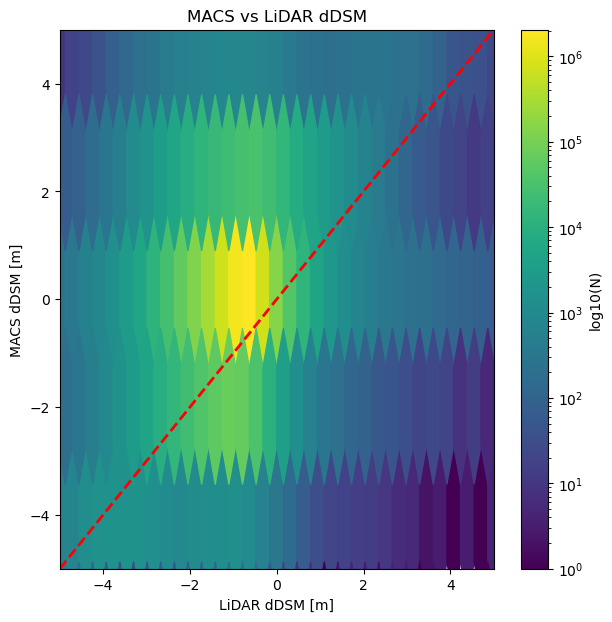

In [119]:
plt.figure(figsize=(7,7))

plt.hexbin(
    x,
    y,
    gridsize=150,
    bins='log',
    mincnt=1
)

plt.plot(
    [-5, 5],
    [-5, 5],
    'r--',
    linewidth=2
)

plt.xlabel('LiDAR dDSM [m]')
plt.ylabel('MACS dDSM [m]')
plt.title('MACS vs LiDAR dDSM')

cb = plt.colorbar()
cb.set_label('log10(N)')

plt.xlim(-5,5)
plt.ylim(-5,5)

plt.show()

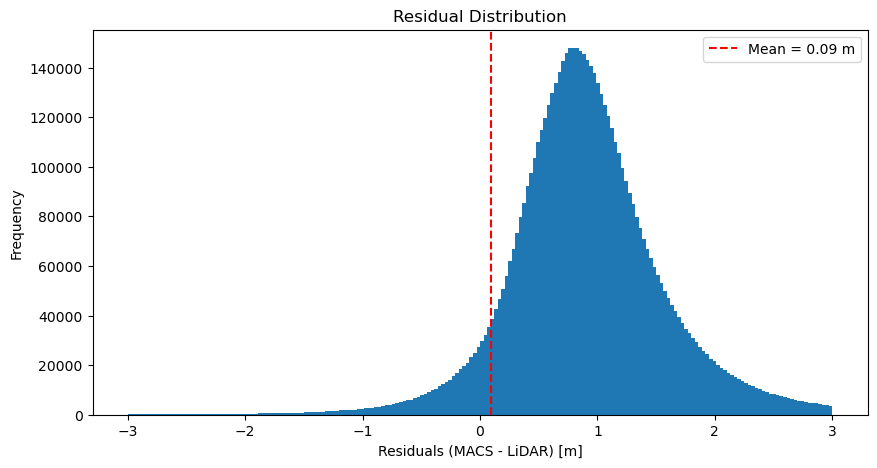

In [ ]:
residuals = y - x

plt.figure(figsize=(10,5))

plt.hist(
    residuals,
    bins=200,
    range=(-3,3)
)

plt.axvline(
    np.mean(residuals),
    color='red',
    linestyle='--',
    label=f'Mean = {np.mean(residuals):.2f} m'
)

plt.xlabel('Residuals (MACS - LiDAR) [m]')
plt.ylabel('Frequency')
plt.title('Residual Distribution')

plt.legend()
plt.show()

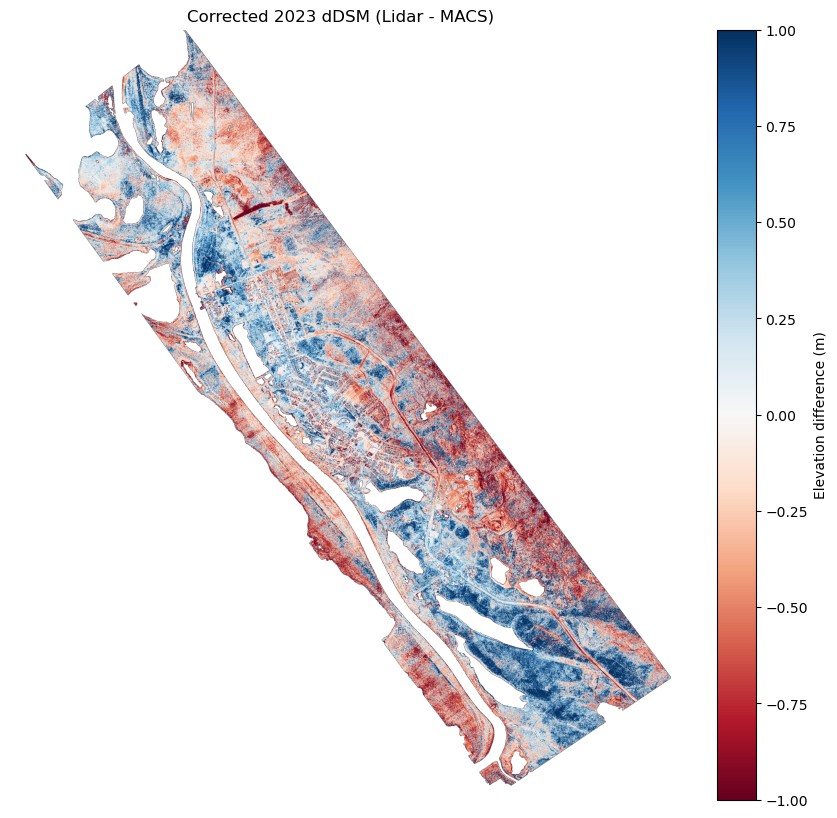

In [113]:
ddsm = dsm2_resampled - dsm1

ddsm = np.where(
    np.abs(ddsm) > 20,
    np.nan,
    ddsm
)
bias = np.nanmedian(ddsm)

ddsm_corr = ddsm - bias
# Optional: mask extreme artefacts
ddsm_corr = np.where(
    np.abs(ddsm_corr) > 20,
    np.nan,
    ddsm_corr
)

plt.figure(figsize=(12,10))

im = plt.imshow(
    ddsm_corr,
    cmap="RdBu",
    vmin=-1,
    vmax=1
)

plt.colorbar(im, label="Elevation difference (m)")

plt.title("Corrected 2023 dDSM (Lidar - MACS)")
plt.axis("off")

#plt.savefig(f"{output_path}2023_corrected_dDSM_ICP_c1.png", dpi=300)

plt.show()

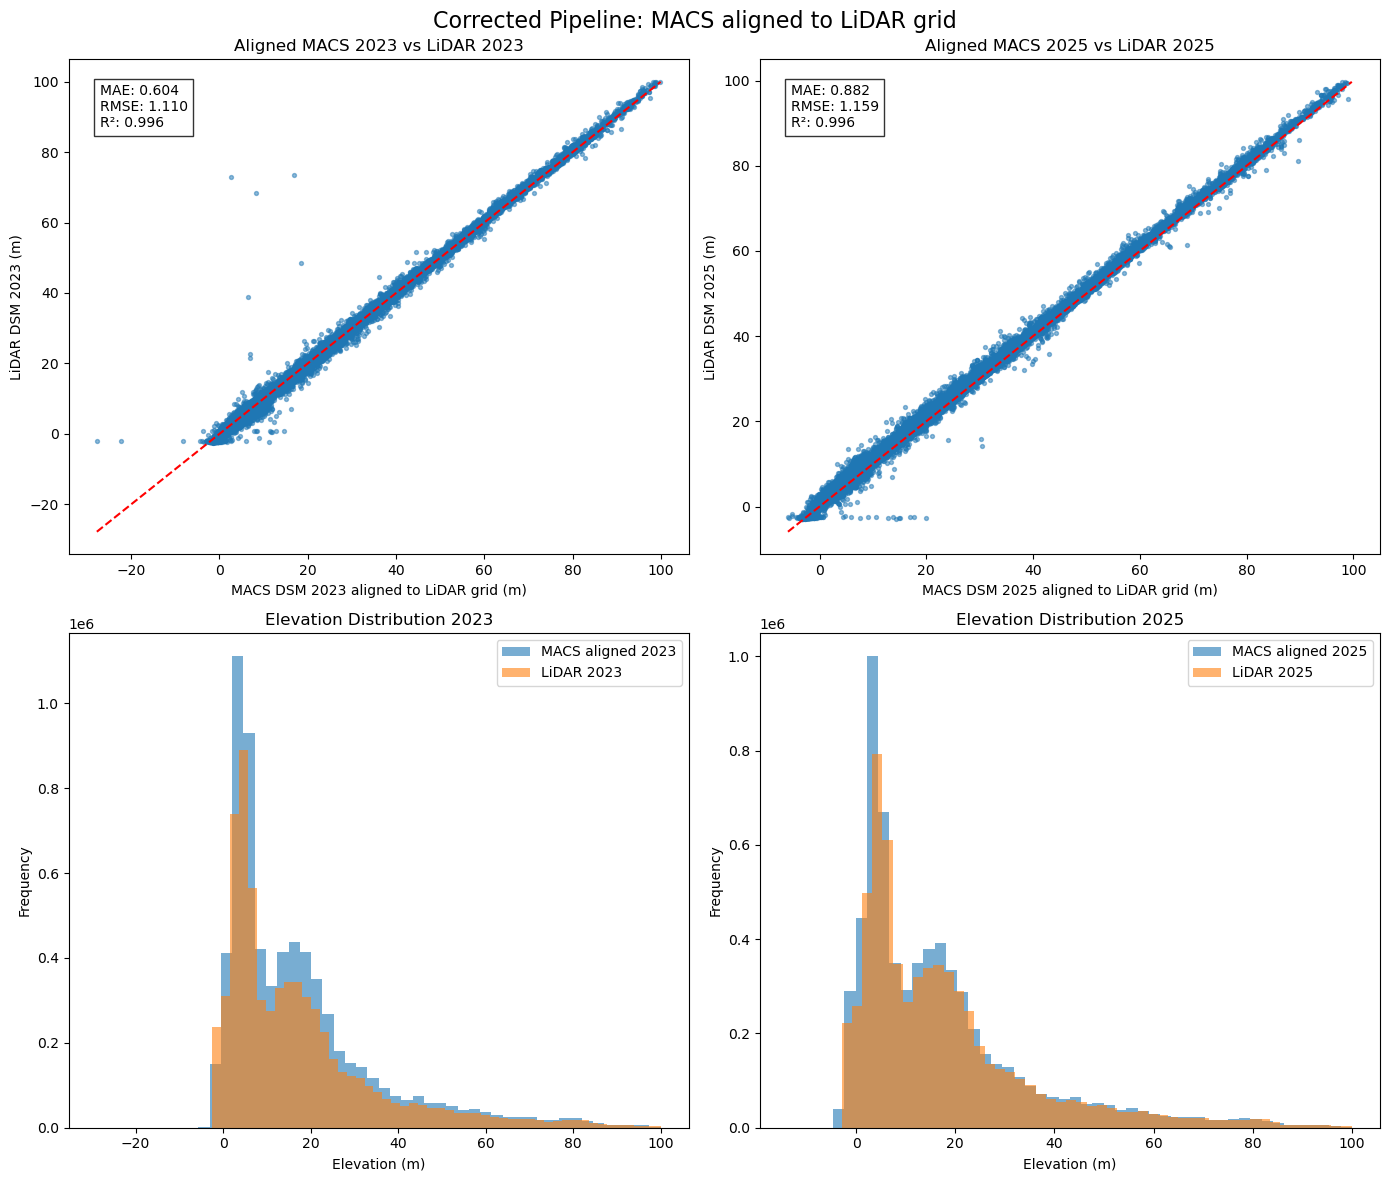

In [2]:
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ============================================================
# FILE PATHS
# ============================================================

macs_2023_path = "/isipd/projects/Response/GIS_RS_projects/Masterarbeit_Till_Weiss/MACS_Ortho_imgs/WC_Inuvik_20230705_15cm_01/Macs_Inuvik_2023_DSM_2m.tif"
lidar_2023_path = "/isipd/projects/p_planetdw/data/lidar/05_results/Perma-X-2023-Till/DSM/Inuvik_DSM_2023_2m.tif"

macs_2025_path = "/isipd/projects/Response/GIS_RS_projects/Masterarbeit_Till_Weiss/MACS_Ortho_imgs/WC_Inuvik_20250727_15cm_01/Inuvik_2025DSM_2m.tif"
lidar_2025_path = "/isipd/projects/p_planetdw/data/lidar/05_results/Perma-X-2025-Till/DSM/Inuvik_DSM_2025_2m.tif"

# ============================================================
# FUNCTION: ALIGN TO REFERENCE GRID
# ============================================================

def align_to_reference(src_path, ref_path):

    with rasterio.open(ref_path) as ref:

        ref_data = ref.read(1)

        ref_transform = ref.transform
        ref_crs = ref.crs
        ref_shape = ref_data.shape

    with rasterio.open(src_path) as src:

        aligned = np.empty(ref_shape, dtype=np.float32)

        reproject(
            source=rasterio.band(src, 1),
            destination=aligned,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=Resampling.bilinear
        )

    return aligned, ref_data


# ============================================================
# ALIGN DATASETS
# ============================================================

macs_2023, lidar_2023 = align_to_reference(
    macs_2023_path,
    lidar_2023_path
)

macs_2025, lidar_2025 = align_to_reference(
    macs_2025_path,
    lidar_2025_path
)

# ============================================================
# MASK VALID PIXELS
# ============================================================

mask23 = (
    np.isfinite(macs_2023) &
    np.isfinite(lidar_2023)
)

mask25 = (
    np.isfinite(macs_2025) &
    np.isfinite(lidar_2025)
)

m23 = macs_2023[mask23]
l23 = lidar_2023[mask23]

m25 = macs_2025[mask25]
l25 = lidar_2025[mask25]

# ============================================================
# OPTIONAL OUTLIER FILTER
# ============================================================

valid23 = (
    (m23 > -100) & (m23 < 100) &
    (l23 > -100) & (l23 < 100)
)

valid25 = (
    (m25 > -100) & (m25 < 100) &
    (l25 > -100) & (l25 < 100)
)

m23 = m23[valid23]
l23 = l23[valid23]

m25 = m25[valid25]
l25 = l25[valid25]

# ============================================================
# METRICS
# ============================================================

def compute_metrics(ref, test):

    mae = mean_absolute_error(ref, test)

    rmse = np.sqrt(mean_squared_error(ref, test))

    r2 = r2_score(ref, test)

    return mae, rmse, r2


mae23, rmse23, r223 = compute_metrics(l23, m23)

mae25, rmse25, r225 = compute_metrics(l25, m25)

# ============================================================
# SAMPLE DATA FOR SCATTER
# (avoids plotting millions of points)
# ============================================================

n = 50000

idx23 = np.random.choice(len(m23), n, replace=False)
idx25 = np.random.choice(len(m25), n, replace=False)

m23_sample = m23[idx23]
l23_sample = l23[idx23]

m25_sample = m25[idx25]
l25_sample = l25[idx25]

# ============================================================
# PLOTTING
# ============================================================

fig, axs = plt.subplots(
    2,
    2,
    figsize=(14, 12)
)

# ============================================================
# TOP LEFT: 2023 SCATTER
# ============================================================

axs[0,0].scatter(
    m23_sample,
    l23_sample,
    s=8,
    alpha=0.5
)

minv = min(np.min(m23_sample), np.min(l23_sample))
maxv = max(np.max(m23_sample), np.max(l23_sample))

axs[0,0].plot(
    [minv, maxv],
    [minv, maxv],
    'r--'
)

axs[0,0].set_title("Aligned MACS 2023 vs LiDAR 2023")

axs[0,0].set_xlabel("MACS DSM 2023 aligned to LiDAR grid (m)")
axs[0,0].set_ylabel("LiDAR DSM 2023 (m)")

axs[0,0].text(
    0.05,
    0.95,
    f"MAE: {mae23:.3f}\nRMSE: {rmse23:.3f}\nR²: {r223:.3f}",
    transform=axs[0,0].transAxes,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.8)
)

# ============================================================
# TOP RIGHT: 2025 SCATTER
# ============================================================

axs[0,1].scatter(
    m25_sample,
    l25_sample,
    s=8,
    alpha=0.5
)

minv = min(np.min(m25_sample), np.min(l25_sample))
maxv = max(np.max(m25_sample), np.max(l25_sample))

axs[0,1].plot(
    [minv, maxv],
    [minv, maxv],
    'r--'
)

axs[0,1].set_title("Aligned MACS 2025 vs LiDAR 2025")

axs[0,1].set_xlabel("MACS DSM 2025 aligned to LiDAR grid (m)")
axs[0,1].set_ylabel("LiDAR DSM 2025 (m)")

axs[0,1].text(
    0.05,
    0.95,
    f"MAE: {mae25:.3f}\nRMSE: {rmse25:.3f}\nR²: {r225:.3f}",
    transform=axs[0,1].transAxes,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.8)
)

# ============================================================
# BOTTOM LEFT: HISTOGRAM 2023
# ============================================================

axs[1,0].hist(
    m23,
    bins=50,
    alpha=0.6,
    label="MACS aligned 2023"
)

axs[1,0].hist(
    l23,
    bins=50,
    alpha=0.6,
    label="LiDAR 2023"
)

axs[1,0].set_title("Elevation Distribution 2023")

axs[1,0].set_xlabel("Elevation (m)")
axs[1,0].set_ylabel("Frequency")

axs[1,0].legend()

# ============================================================
# BOTTOM RIGHT: HISTOGRAM 2025
# ============================================================

axs[1,1].hist(
    m25,
    bins=50,
    alpha=0.6,
    label="MACS aligned 2025"
)

axs[1,1].hist(
    l25,
    bins=50,
    alpha=0.6,
    label="LiDAR 2025"
)

axs[1,1].set_title("Elevation Distribution 2025")

axs[1,1].set_xlabel("Elevation (m)")
axs[1,1].set_ylabel("Frequency")

axs[1,1].legend()

# ============================================================
# FINAL LAYOUT
# ============================================================

plt.suptitle(
    "Corrected Pipeline: MACS aligned to LiDAR grid",
    fontsize=16
)

plt.tight_layout()
plt.savefig(f"{output_path}MACS_vs_LiDAR_comparison_yearly.png", dpi=300)
plt.show()

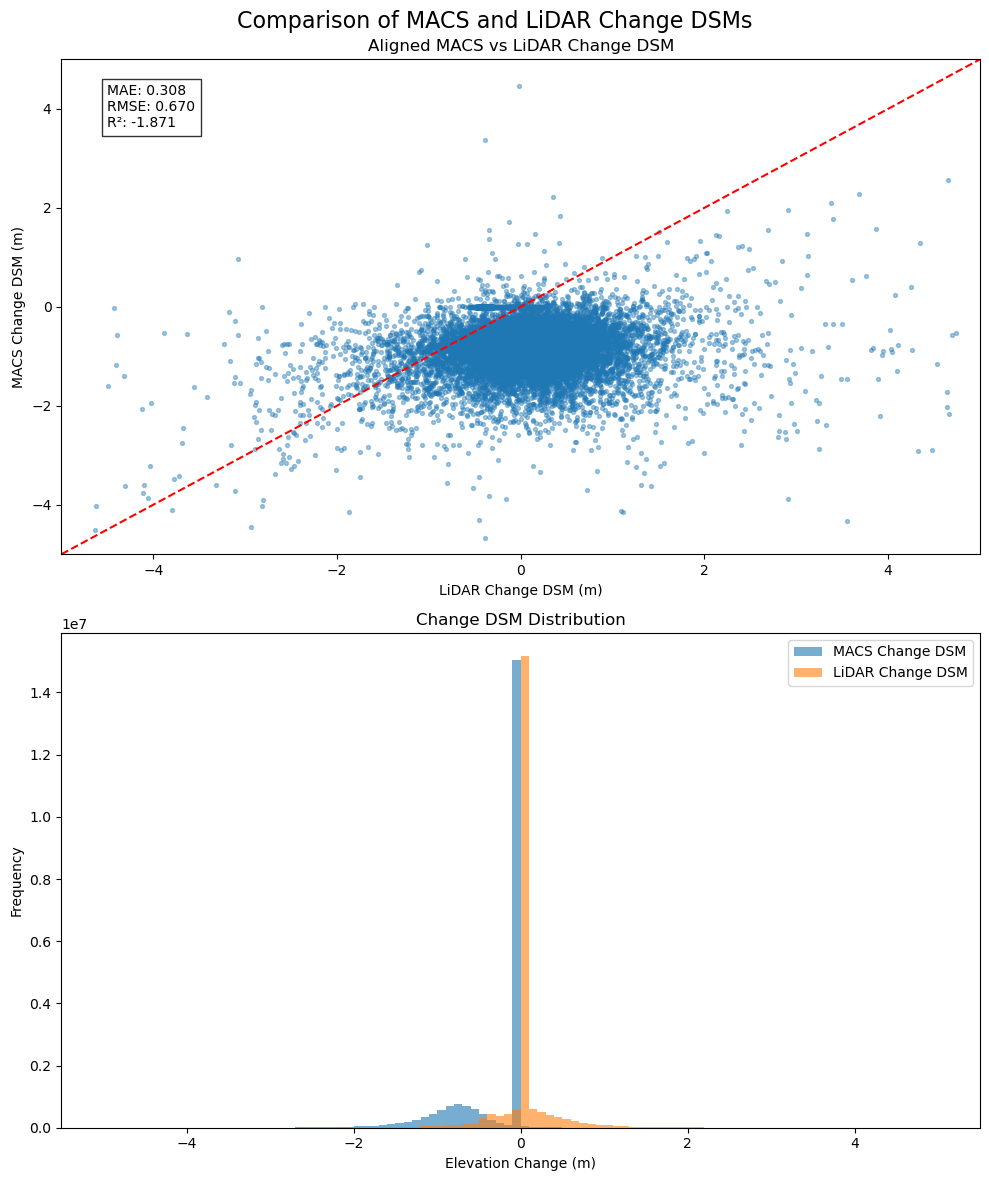

In [3]:
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ============================================================
# FILE PATHS
# ============================================================

macs_2023_path = "/isipd/projects/Response/GIS_RS_projects/Masterarbeit_Till_Weiss/MACS_Ortho_imgs/WC_Inuvik_20230705_15cm_01/Macs_Inuvik_2023_DSM_2m.tif"
lidar_2023_path = "/isipd/projects/p_planetdw/data/lidar/05_results/Perma-X-2023-Till/DSM/Inuvik_DSM_2023_2m.tif"

macs_2025_path = "/isipd/projects/Response/GIS_RS_projects/Masterarbeit_Till_Weiss/MACS_Ortho_imgs/WC_Inuvik_20250727_15cm_01/Inuvik_2025DSM_2m.tif"
lidar_2025_path = "/isipd/projects/p_planetdw/data/lidar/05_results/Perma-X-2025-Till/DSM/Inuvik_DSM_2025_2m.tif"


# ============================================================
# FUNCTION: ALIGN TO REFERENCE GRID
# ============================================================

def align_to_reference(src_path, ref_path):

    with rasterio.open(ref_path) as ref:

        ref_data = ref.read(1)

        ref_transform = ref.transform
        ref_crs = ref.crs
        ref_shape = ref_data.shape

    with rasterio.open(src_path) as src:

        aligned = np.empty(ref_shape, dtype=np.float32)

        reproject(
            source=rasterio.band(src, 1),
            destination=aligned,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=Resampling.bilinear
        )

    return aligned


# ============================================================
# ALIGN ALL DSMs TO SAME GRID
# ============================================================

macs_2023 = align_to_reference(
    macs_2023_path,
    lidar_2023_path
)

macs_2025 = align_to_reference(
    macs_2025_path,
    lidar_2023_path
)

lidar_2023 = align_to_reference(
    lidar_2023_path,
    lidar_2023_path
)

lidar_2025 = align_to_reference(
    lidar_2025_path,
    lidar_2023_path
)

# ============================================================
# CREATE CHANGE DSMs
# ============================================================

macs_ddsm = macs_2025 - macs_2023

lidar_ddsm = lidar_2025 - lidar_2023

# ============================================================
# VALID MASK
# ============================================================

mask = (
    np.isfinite(macs_ddsm) &
    np.isfinite(lidar_ddsm)
)

m = macs_ddsm[mask]
l = lidar_ddsm[mask]

# ============================================================
# OPTIONAL FILTER
# ============================================================

valid = (
    (np.abs(m) < 5) &
    (np.abs(l) < 5)
)

m = m[valid]
l = l[valid]

# ============================================================
# METRICS
# ============================================================

mae = mean_absolute_error(l, m)

rmse = np.sqrt(mean_squared_error(l, m))

r2 = r2_score(l, m)

# ============================================================
# SAMPLE DATA FOR SCATTER
# ============================================================

n = min(50000, len(m))

idx = np.random.choice(
    len(m),
    n,
    replace=False
)

m_sample = m[idx]
l_sample = l[idx]

# ============================================================
# FIGURE
# ============================================================

fig, axs = plt.subplots(
    2,
    1,
    figsize=(10, 12)
)

# ============================================================
# TOP: SCATTER PLOT
# ============================================================

axs[0].scatter(
    l_sample,
    m_sample,
    s=8,
    alpha=0.4
)

axs[0].plot(
    [-5, 5],
    [-5, 5],
    'r--'
)

axs[0].set_xlim(-5, 5)
axs[0].set_ylim(-5, 5)

axs[0].set_xlabel("LiDAR Change DSM (m)")
axs[0].set_ylabel("MACS Change DSM (m)")

axs[0].set_title(
    "Aligned MACS vs LiDAR Change DSM"
)

axs[0].text(
    0.05,
    0.95,
    (
        f"MAE: {mae:.3f}\n"
        f"RMSE: {rmse:.3f}\n"
        f"R²: {r2:.3f}"
    ),
    transform=axs[0].transAxes,
    verticalalignment='top',
    bbox=dict(
        facecolor='white',
        alpha=0.8
    )
)

# ============================================================
# BOTTOM: OVERLAID HISTOGRAMS
# ============================================================

axs[1].hist(
    m,
    bins=100,
    alpha=0.6,
    label="MACS Change DSM"
)

axs[1].hist(
    l,
    bins=100,
    alpha=0.6,
    label="LiDAR Change DSM"
)

axs[1].set_title(
    "Change DSM Distribution"
)

axs[1].set_xlabel("Elevation Change (m)")
axs[1].set_ylabel("Frequency")

axs[1].legend()

# ============================================================
# FINAL LAYOUT
# ============================================================

plt.suptitle(
    "Comparison of MACS and LiDAR Change DSMs",
    fontsize=16
)

plt.tight_layout()

plt.savefig(f"{output_path}MACS_vs_LiDAR_comparison_dDSM.png", dpi=300)

plt.show()

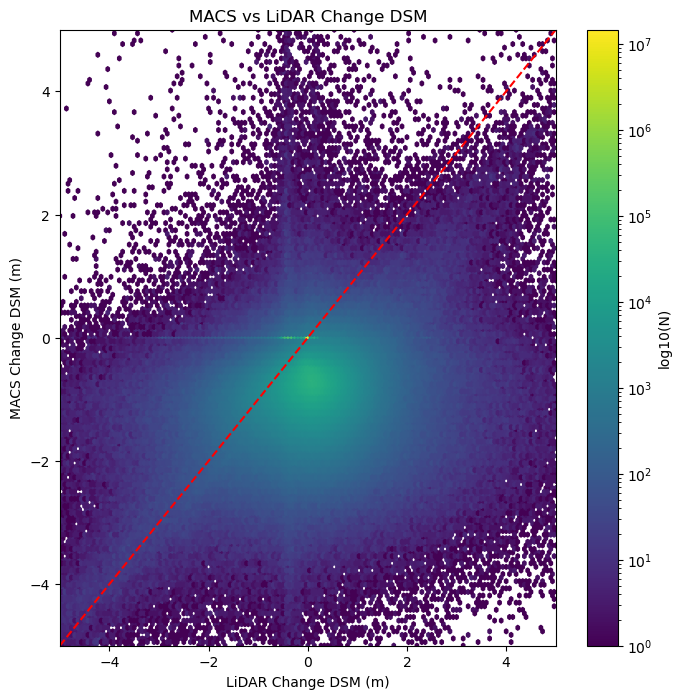

In [134]:
plt.figure(figsize=(8,8))

hb = plt.hexbin(
    l,
    m,
    gridsize=150,
    bins='log',
    mincnt=1
)

plt.plot(
    [-5,5],
    [-5,5],
    'r--'
)

plt.xlabel("LiDAR Change DSM (m)")
plt.ylabel("MACS Change DSM (m)")

plt.xlim(-5,5)
plt.ylim(-5,5)

cb = plt.colorbar(hb)
cb.set_label("log10(N)")

plt.title("MACS vs LiDAR Change DSM")

plt.show()

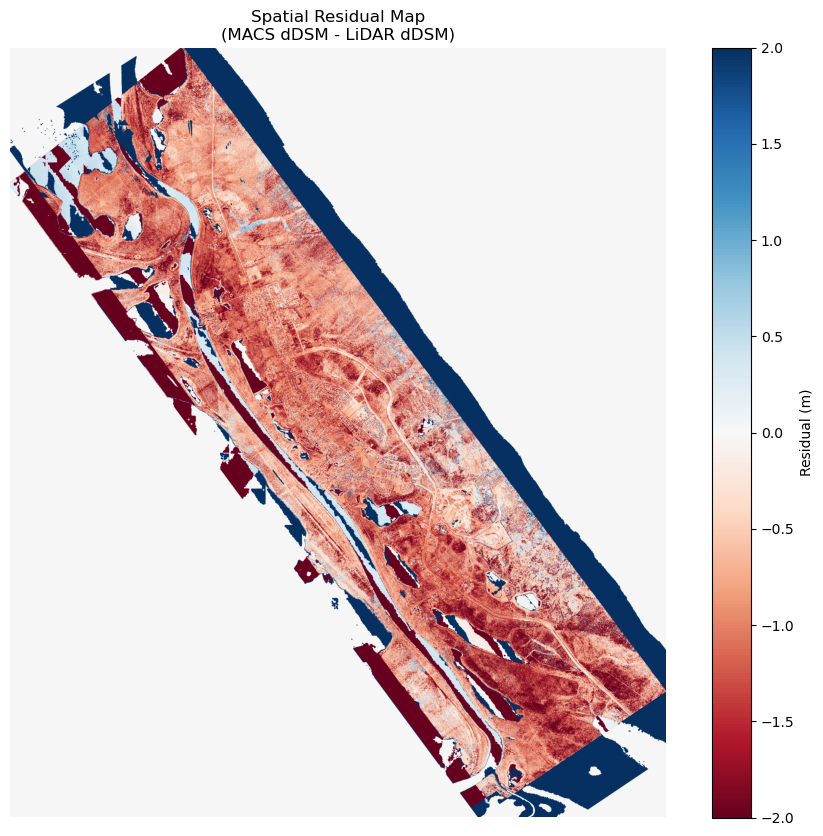

In [135]:
residual_map = macs_ddsm - lidar_ddsm

plt.figure(figsize=(12,10))

im = plt.imshow(
    np.ma.masked_invalid(residual_map),
    cmap='RdBu',
    vmin=-2,
    vmax=2
)

plt.colorbar(im, label="Residual (m)")

plt.title("Spatial Residual Map\n(MACS dDSM - LiDAR dDSM)")

plt.axis('off')

plt.show()


Original Stable Ground CRS:
EPSG:4326

Stable Ground Bounds:
[-133.76558889   68.35371685 -133.70432219   68.40094563]

Corrected Stable Ground CRS:
PROJCS["WGS 84 / UTM zone 8N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-135],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32608"]]

Stable mask pixels:
2023: 5185
2025: 5199

Valid overlapping stable pixels:
2023: 5185
2025: 5199

2023 Stable Ground Statistics
MAE:     0.845
RMSE:    0.865
R²:      0.952
Mean:    0.841
Median:  0.843
STD:     0.200
NMAD:    0.108

2025 Stable Gro

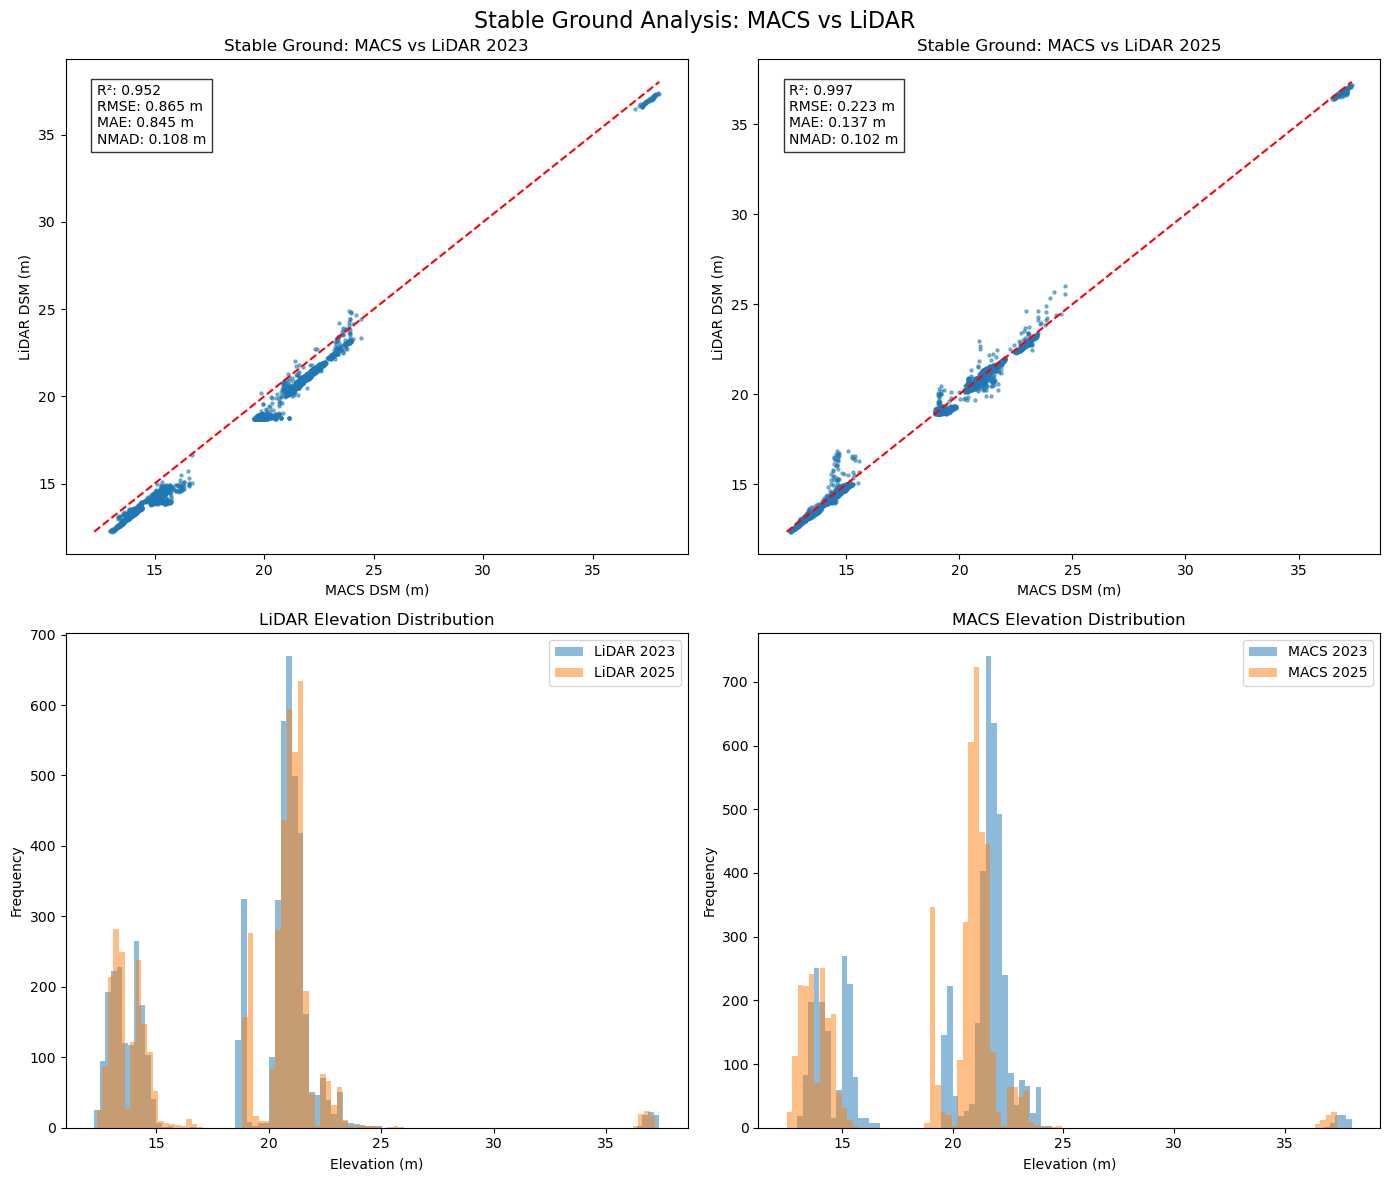

In [31]:
import numpy as np
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt

from rasterio.warp import reproject, Resampling
from rasterio.features import rasterize

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ============================================================
# FILE PATHS
# ============================================================

macs_2023_path = "/isipd/projects/Response/GIS_RS_projects/Masterarbeit_Till_Weiss/MACS_Ortho_imgs/WC_Inuvik_20230705_15cm_01/Macs_Inuvik_2023_DSM_2m.tif"

lidar_2023_path = "/isipd/projects/p_planetdw/data/lidar/05_results/Perma-X-2023-Till/DSM/Inuvik_DSM_2023_2m.tif"

macs_2025_path = "/isipd/projects/Response/GIS_RS_projects/Masterarbeit_Till_Weiss/MACS_Ortho_imgs/WC_Inuvik_20250727_15cm_01/Inuvik_2025DSM_2m.tif"

lidar_2025_path = "/isipd/projects/p_planetdw/data/lidar/05_results/Perma-X-2025-Till/DSM/Inuvik_DSM_2025_2m.tif"

stable_ground_gpkg = "/isipd/projects/Response/GIS_RS_projects/Masterarbeit_Till_Weiss/AOI/stable_ground.gpkg"

output_path = "./"

# ============================================================
# FUNCTION: ALIGN TO REFERENCE GRID
# ============================================================

def align_to_reference(src_path, ref_path):

    with rasterio.open(ref_path) as ref:

        ref_data = ref.read(1)

        ref_transform = ref.transform
        ref_crs = ref.crs
        ref_shape = ref_data.shape

    with rasterio.open(src_path) as src:

        aligned = np.empty(ref_shape, dtype=np.float32)

        reproject(
            source=rasterio.band(src, 1),
            destination=aligned,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=Resampling.max
        )

    return aligned, ref_data, ref_transform, ref_crs

# ============================================================
# ALIGN DATASETS
# ============================================================

macs_2023, lidar_2023, transform23, crs23 = align_to_reference(
    macs_2023_path,
    lidar_2023_path
)

macs_2025, lidar_2025, transform25, crs25 = align_to_reference(
    macs_2025_path,
    lidar_2025_path
)

# ============================================================
# REMOVE INVALID VALUES
# ============================================================

macs_2023[macs_2023 < -100] = np.nan
macs_2025[macs_2025 < -100] = np.nan

lidar_2023[lidar_2023 < -100] = np.nan
lidar_2025[lidar_2025 < -100] = np.nan

# ============================================================
# LOAD STABLE GROUND
# ============================================================

stable_gdf = gpd.read_file(stable_ground_gpkg)

print("\nOriginal Stable Ground CRS:")
print(stable_gdf.crs)

print("\nStable Ground Bounds:")
print(stable_gdf.total_bounds)

# ============================================================
# FIX CRS
# ============================================================

stable_gdf = stable_gdf.to_crs(crs23)

print("\nCorrected Stable Ground CRS:")
print(stable_gdf.crs)

# ============================================================
# OPTIONAL BUFFER
# ============================================================

stable_gdf["geometry"] = stable_gdf.buffer(2)

# ============================================================
# CREATE STABLE MASKS
# ============================================================

stable_mask23 = rasterize(
    [(geom, 1) for geom in stable_gdf.geometry],
    out_shape=lidar_2023.shape,
    transform=transform23,
    fill=0,
    dtype="uint8"
).astype(bool)

stable_mask25 = rasterize(
    [(geom, 1) for geom in stable_gdf.geometry],
    out_shape=lidar_2025.shape,
    transform=transform25,
    fill=0,
    dtype="uint8"
).astype(bool)

# ============================================================
# DEBUG
# ============================================================

print("\nStable mask pixels:")
print("2023:", np.sum(stable_mask23))
print("2025:", np.sum(stable_mask25))

# ============================================================
# CREATE VALID MASKS
# ============================================================

mask23 = (
    np.isfinite(macs_2023) &
    np.isfinite(lidar_2023) &
    stable_mask23
)

mask25 = (
    np.isfinite(macs_2025) &
    np.isfinite(lidar_2025) &
    stable_mask25
)

print("\nValid overlapping stable pixels:")
print("2023:", np.sum(mask23))
print("2025:", np.sum(mask25))

# ============================================================
# EXTRACT STABLE VALUES
# ============================================================

m23 = macs_2023[mask23]
l23 = lidar_2023[mask23]

m25 = macs_2025[mask25]
l25 = lidar_2025[mask25]

# ============================================================
# RESIDUALS
# ============================================================

res23 = m23 - l23
res25 = m25 - l25

# ============================================================
# NMAD FUNCTION
# ============================================================

def compute_nmad(data):

    med = np.median(data)

    nmad = 1.4826 * np.median(
        np.abs(data - med)
    )

    return nmad

# ============================================================
# METRICS FUNCTION
# ============================================================

def compute_metrics(ref, test):

    residuals = test - ref

    mae = mean_absolute_error(ref, test)

    rmse = np.sqrt(
        mean_squared_error(ref, test)
    )

    r2 = r2_score(ref, test)

    mean = np.mean(residuals)

    median = np.median(residuals)

    std = np.std(residuals)

    nmad = compute_nmad(residuals)

    return (
        mae,
        rmse,
        r2,
        mean,
        median,
        std,
        nmad
    )

# ============================================================
# COMPUTE METRICS
# ============================================================

(
    mae23,
    rmse23,
    r223,
    mean23,
    med23,
    std23,
    nmad23
) = compute_metrics(l23, m23)

(
    mae25,
    rmse25,
    r225,
    mean25,
    med25,
    std25,
    nmad25
) = compute_metrics(l25, m25)

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n===================================")
print("2023 Stable Ground Statistics")
print("===================================")

print(f"MAE:     {mae23:.3f}")
print(f"RMSE:    {rmse23:.3f}")
print(f"R²:      {r223:.3f}")
print(f"Mean:    {mean23:.3f}")
print(f"Median:  {med23:.3f}")
print(f"STD:     {std23:.3f}")
print(f"NMAD:    {nmad23:.3f}")

print("\n===================================")
print("2025 Stable Ground Statistics")
print("===================================")

print(f"MAE:     {mae25:.3f}")
print(f"RMSE:    {rmse25:.3f}")
print(f"R²:      {r225:.3f}")
print(f"Mean:    {mean25:.3f}")
print(f"Median:  {med25:.3f}")
print(f"STD:     {std25:.3f}")
print(f"NMAD:    {nmad25:.3f}")

# ============================================================
# PLOTS
# ============================================================

fig, axs = plt.subplots(
    2,
    2,
    figsize=(14, 12)
)

# ============================================================
# SCATTER 2023
# ============================================================

sample_size = min(50000, len(m23))

idx = np.random.choice(
    len(m23),
    sample_size,
    replace=False
)

axs[0,0].scatter(
    m23[idx],
    l23[idx],
    s=5,
    alpha=0.5
)

minv = min(
    np.min(m23[idx]),
    np.min(l23[idx])
)

maxv = max(
    np.max(m23[idx]),
    np.max(l23[idx])
)

axs[0,0].plot(
    [minv, maxv],
    [minv, maxv],
    'r--'
)

axs[0,0].set_title(
    "Stable Ground: MACS vs LiDAR 2023"
)

axs[0,0].set_xlabel("MACS DSM (m)")
axs[0,0].set_ylabel("LiDAR DSM (m)")

axs[0,0].text(
    0.05,
    0.95,
    (
        f"R²: {r223:.3f}\n"
        f"RMSE: {rmse23:.3f} m\n"
        f"MAE: {mae23:.3f} m\n"
        f"NMAD: {nmad23:.3f} m"
    ),
    transform=axs[0,0].transAxes,
    verticalalignment='top',
    bbox=dict(
        facecolor='white',
        alpha=0.8
    )
)

# ============================================================
# SCATTER 2025
# ============================================================

sample_size = min(50000, len(m25))

idx = np.random.choice(
    len(m25),
    sample_size,
    replace=False
)

axs[0,1].scatter(
    m25[idx],
    l25[idx],
    s=5,
    alpha=0.5
)

minv = min(
    np.min(m25[idx]),
    np.min(l25[idx])
)

maxv = max(
    np.max(m25[idx]),
    np.max(l25[idx])
)

axs[0,1].plot(
    [minv, maxv],
    [minv, maxv],
    'r--'
)

axs[0,1].set_title(
    "Stable Ground: MACS vs LiDAR 2025"
)

axs[0,1].set_xlabel("MACS DSM (m)")
axs[0,1].set_ylabel("LiDAR DSM (m)")

axs[0,1].text(
    0.05,
    0.95,
    (
        f"R²: {r225:.3f}\n"
        f"RMSE: {rmse25:.3f} m\n"
        f"MAE: {mae25:.3f} m\n"
        f"NMAD: {nmad25:.3f} m"
    ),
    transform=axs[0,1].transAxes,
    verticalalignment='top',
    bbox=dict(
        facecolor='white',
        alpha=0.8
    )
)

# ============================================================
# LIDAR ELEVATION DISTRIBUTION
# ============================================================

axs[1,0].hist(
    l23,
    bins=100,
    alpha=0.5,
    label="LiDAR 2023"
)

axs[1,0].hist(
    l25,
    bins=100,
    alpha=0.5,
    label="LiDAR 2025"
)

axs[1,0].set_title(
    "LiDAR Elevation Distribution"
)

axs[1,0].set_xlabel(
    "Elevation (m)"
)

axs[1,0].set_ylabel(
    "Frequency"
)

axs[1,0].legend()

# ============================================================
# MACS ELEVATION DISTRIBUTION
# ============================================================

axs[1,1].hist(
    m23,
    bins=100,
    alpha=0.5,
    label="MACS 2023"
)

axs[1,1].hist(
    m25,
    bins=100,
    alpha=0.5,
    label="MACS 2025"
)

axs[1,1].set_title(
    "MACS Elevation Distribution"
)

axs[1,1].set_xlabel(
    "Elevation (m)"
)

axs[1,1].set_ylabel(
    "Frequency"
)

axs[1,1].legend()

# ============================================================
# FINAL LAYOUT
# ============================================================

plt.suptitle(
    "Stable Ground Analysis: MACS vs LiDAR",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    f"{output_path}stable_ground_analysis.png",
    dpi=300
)

plt.show()


Original CRS:
EPSG:4326

Original Bounds:
[-133.76558889   68.35371685 -133.70432219   68.40094563]

Reprojected Bounds:
[ 550708.51321685 7582861.52350047  553334.0160886  7588075.21282246]

Stable mask pixels:
5185

Valid stable pixels:
5185

Stable Ground dDSM Statistics
MAE:     0.784
RMSE:    0.830
R²:      -12.194
Mean:    -0.777
Median:  -0.753
STD:     0.291
NMAD:    0.212


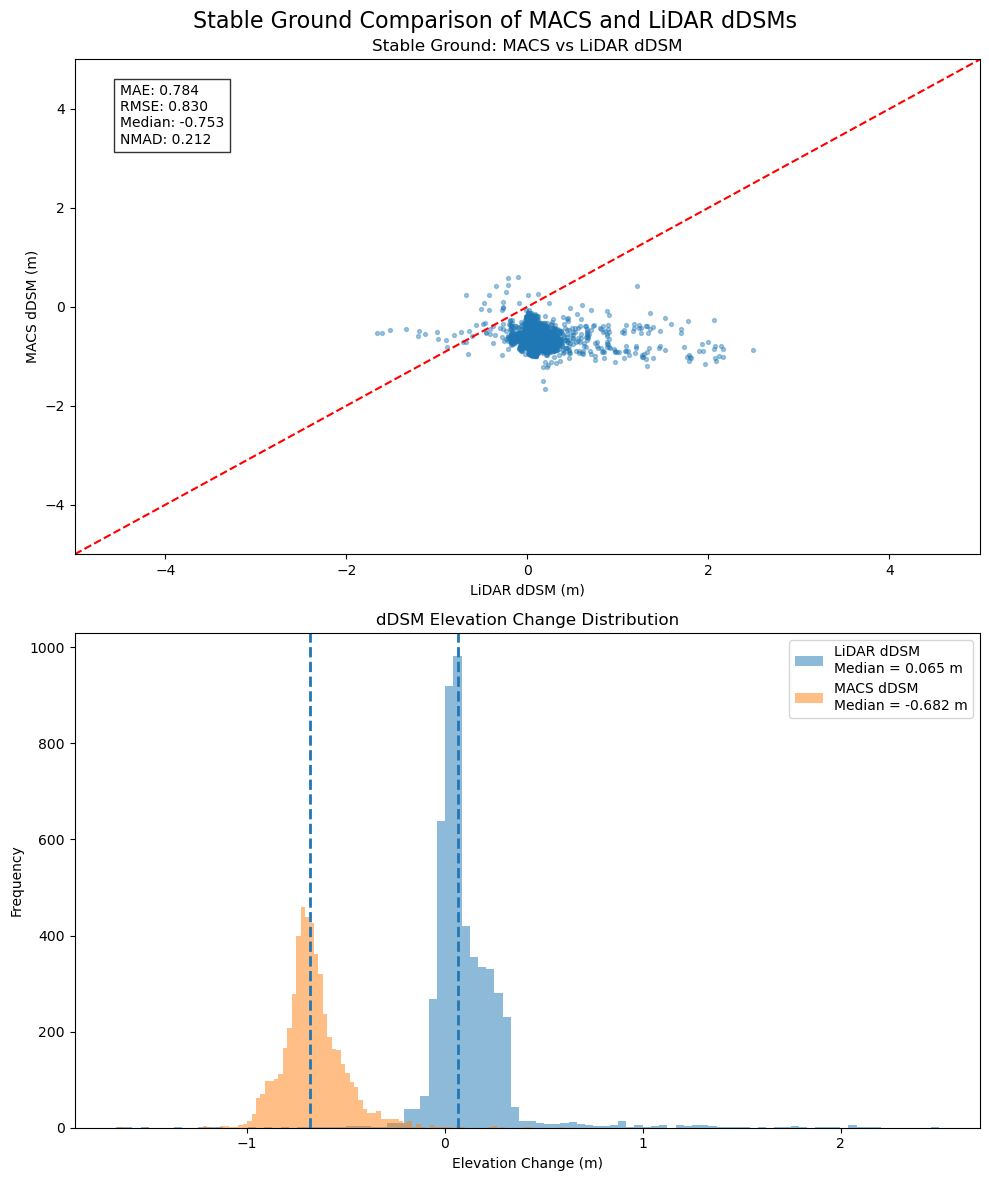

In [47]:
import numpy as np
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt

from rasterio.warp import reproject, Resampling
from rasterio.features import rasterize

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ============================================================
# FILE PATHS
# ============================================================

macs_2023_path = "/isipd/projects/Response/GIS_RS_projects/Masterarbeit_Till_Weiss/MACS_Ortho_imgs/WC_Inuvik_20230705_15cm_01/Macs_Inuvik_2023_DSM_2m.tif"

lidar_2023_path = "/isipd/projects/p_planetdw/data/lidar/05_results/Perma-X-2023-Till/DSM/Inuvik_DSM_2023_2m.tif"

macs_2025_path = "/isipd/projects/Response/GIS_RS_projects/Masterarbeit_Till_Weiss/MACS_Ortho_imgs/WC_Inuvik_20250727_15cm_01/Inuvik_2025DSM_2m.tif"

lidar_2025_path = "/isipd/projects/p_planetdw/data/lidar/05_results/Perma-X-2025-Till/DSM/Inuvik_DSM_2025_2m.tif"

stable_ground_gpkg = "/isipd/projects/Response/GIS_RS_projects/Masterarbeit_Till_Weiss/AOI/stable_ground.gpkg"

output_path = "./"

# ============================================================
# FUNCTION: ALIGN TO REFERENCE GRID
# ============================================================

def align_to_reference(src_path, ref_path):

    with rasterio.open(ref_path) as ref:

        ref_data = ref.read(1)

        ref_transform = ref.transform
        ref_crs = ref.crs
        ref_shape = ref_data.shape

    with rasterio.open(src_path) as src:

        aligned = np.empty(ref_shape, dtype=np.float32)

        reproject(
            source=rasterio.band(src, 1),
            destination=aligned,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=Resampling.bilinear
        )

    return aligned, ref_transform, ref_crs

# ============================================================
# ALIGN ALL DSMs TO SAME GRID
# ============================================================

macs_2023, transform, crs = align_to_reference(
    macs_2023_path,
    lidar_2023_path
)

macs_2025, _, _ = align_to_reference(
    macs_2025_path,
    lidar_2023_path
)

lidar_2023, _, _ = align_to_reference(
    lidar_2023_path,
    lidar_2023_path
)

lidar_2025, _, _ = align_to_reference(
    lidar_2025_path,
    lidar_2023_path
)

# ============================================================
# REMOVE INVALID VALUES
# ============================================================

macs_2023[macs_2023 < -100] = np.nan
macs_2025[macs_2025 < -100] = np.nan

lidar_2023[lidar_2023 < -100] = np.nan
lidar_2025[lidar_2025 < -100] = np.nan

# ============================================================
# LOAD STABLE GROUND
# ============================================================

stable_gdf = gpd.read_file(stable_ground_gpkg)

print("\nOriginal CRS:")
print(stable_gdf.crs)

print("\nOriginal Bounds:")
print(stable_gdf.total_bounds)

stable_gdf = stable_gdf.to_crs(crs)

print("\nReprojected Bounds:")
print(stable_gdf.total_bounds)

# ============================================================
# OPTIONAL BUFFER
# ============================================================

stable_gdf["geometry"] = stable_gdf.buffer(2)

# ============================================================
# RASTERIZE STABLE MASK
# ============================================================

stable_mask = rasterize(
    [(geom, 1) for geom in stable_gdf.geometry],
    out_shape=lidar_2023.shape,
    transform=transform,
    fill=0,
    dtype="uint8"
).astype(bool)

print("\nStable mask pixels:")
print(np.sum(stable_mask))

# ============================================================
# CREATE dDSMs
# ============================================================

macs_ddsm = macs_2025 - macs_2023

lidar_ddsm = lidar_2025 - lidar_2023

# ============================================================
# VALID MASK
# ============================================================

mask = (
    np.isfinite(macs_ddsm) &
    np.isfinite(lidar_ddsm) &
    stable_mask
)

print("\nValid stable pixels:")
print(np.sum(mask))

# ============================================================
# EXTRACT STABLE VALUES
# ============================================================

m = macs_ddsm[mask]
l = lidar_ddsm[mask]

# ============================================================
# OPTIONAL FILTER
# ============================================================

valid = (
    (np.abs(m) < 5) &
    (np.abs(l) < 5)
)

m = m[valid]
l = l[valid]

# ============================================================
# RESIDUALS
# ============================================================

residuals = m - l

# ============================================================
# NMAD FUNCTION
# ============================================================

def compute_nmad(data):

    med = np.median(data)

    nmad = 1.4826 * np.median(
        np.abs(data - med)
    )

    return nmad

# ============================================================
# METRICS
# ============================================================

mae = mean_absolute_error(l, m)

rmse = np.sqrt(
    mean_squared_error(l, m)
)

r2 = r2_score(l, m)

mean = np.mean(residuals)

median = np.median(residuals)

std = np.std(residuals)

nmad = compute_nmad(residuals)

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n===================================")
print("Stable Ground dDSM Statistics")
print("===================================")

print(f"MAE:     {mae:.3f}")
print(f"RMSE:    {rmse:.3f}")
print(f"R²:      {r2:.3f}")
print(f"Mean:    {mean:.3f}")
print(f"Median:  {median:.3f}")
print(f"STD:     {std:.3f}")
print(f"NMAD:    {nmad:.3f}")

# ============================================================
# SAMPLE FOR SCATTER
# ============================================================

n = min(50000, len(m))

idx = np.random.choice(
    len(m),
    n,
    replace=False
)

m_sample = m[idx]
l_sample = l[idx]

# ============================================================
# FIGURE
# ============================================================

fig, axs = plt.subplots(
    2,
    1,
    figsize=(10, 12)
)

# ============================================================
# SCATTER
# ============================================================

axs[0].scatter(
    l_sample,
    m_sample,
    s=8,
    alpha=0.4
)

axs[0].plot(
    [-5, 5],
    [-5, 5],
    'r--'
)

axs[0].set_xlim(-5, 5)
axs[0].set_ylim(-5, 5)

axs[0].set_xlabel("LiDAR dDSM (m)")
axs[0].set_ylabel("MACS dDSM (m)")

axs[0].set_title(
    "Stable Ground: MACS vs LiDAR dDSM"
)

axs[0].text(
    0.05,
    0.95,
    (
        f"MAE: {mae:.3f}\n"
        f"RMSE: {rmse:.3f}\n"
        f"Median: {median:.3f}\n"
        f"NMAD: {nmad:.3f}"
    ),
    transform=axs[0].transAxes,
    verticalalignment='top',
    bbox=dict(
        facecolor='white',
        alpha=0.8
    )
)

# ============================================================
# dDSM DISTRIBUTIONS
# ============================================================

median_l = np.median(l)
median_m = np.median(m)

axs[1].hist(
    l,
    bins=100,
    alpha=0.5,
    label=f"LiDAR dDSM\nMedian = {median_l:.3f} m"
)

axs[1].hist(
    m,
    bins=100,
    alpha=0.5,
    label=f"MACS dDSM\nMedian = {median_m:.3f} m"
)

# Median lines
axs[1].axvline(
    median_l,
    linestyle='--',
    linewidth=2
)

axs[1].axvline(
    median_m,
    linestyle='--',
    linewidth=2
)



axs[1].set_title(
    "dDSM Elevation Change Distribution"
)

axs[1].set_xlabel(
    "Elevation Change (m)"
)

axs[1].set_ylabel(
    "Frequency"
)

axs[1].legend()

# ============================================================
# FINAL LAYOUT
# ============================================================

plt.suptitle(
    "Stable Ground Comparison of MACS and LiDAR dDSMs",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    f"{output_path}stable_ground_dDSM_analysis.png",
    dpi=300
)

plt.show()


Original CRS:
EPSG:4326

Original Bounds:
[-133.76558889   68.35371685 -133.70432219   68.40094563]

Reprojected Bounds:
[ 550708.51321685 7582861.52350047  553334.0160886  7588075.21282246]

Stable mask pixels:
5185

Valid stable pixels:
5185

Stable Ground dDSM Statistics
MAE:     0.851
RMSE:    0.934
R²:      -6.216
Mean:    -0.847
Median:  -0.782
STD:     0.394
NMAD:    0.218


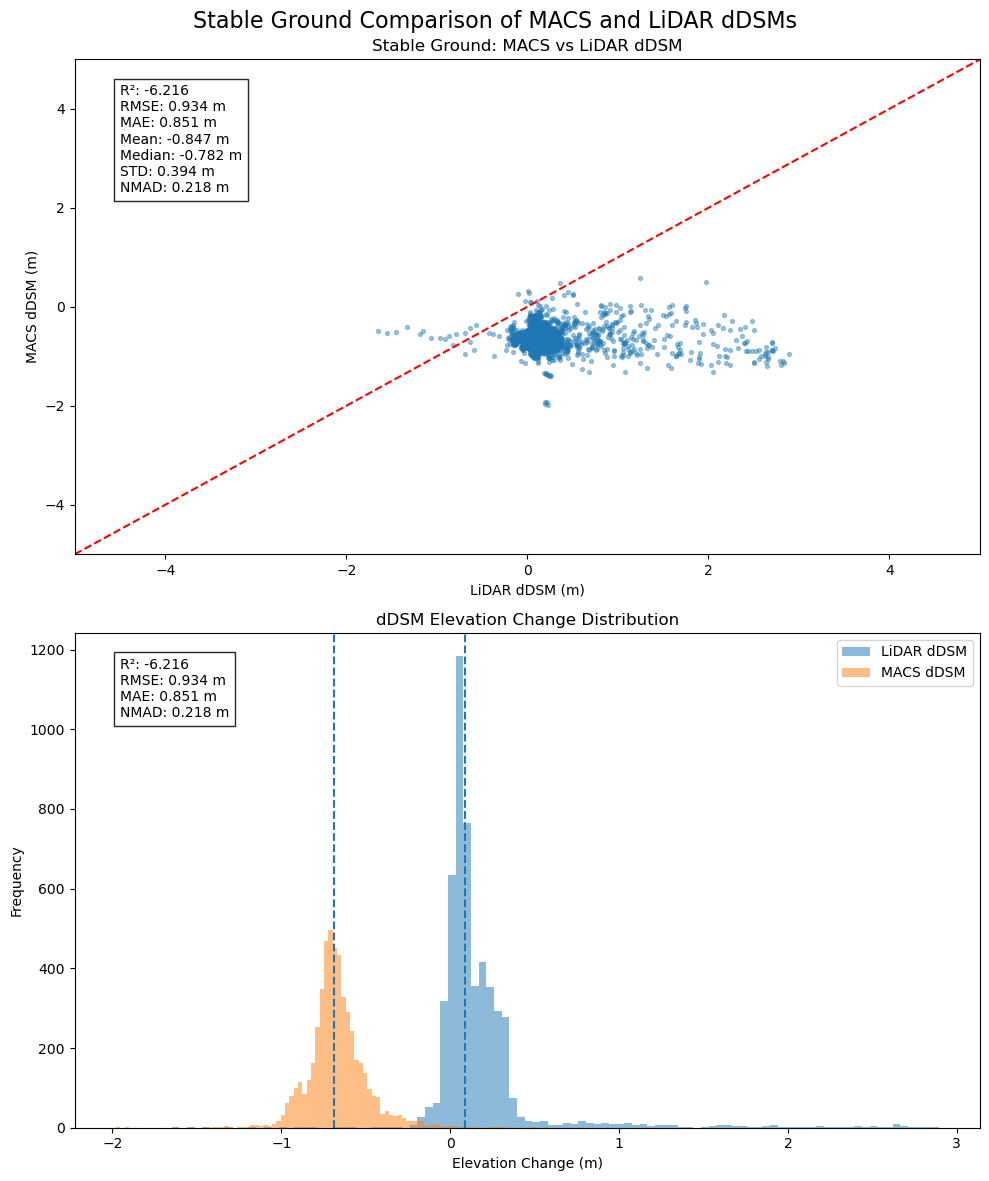

In [33]:
import numpy as np
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt

from rasterio.warp import reproject, Resampling
from rasterio.features import rasterize

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ============================================================
# FILE PATHS
# ============================================================

macs_2023_path = "/isipd/projects/Response/GIS_RS_projects/Masterarbeit_Till_Weiss/MACS_Ortho_imgs/WC_Inuvik_20230705_15cm_01/Macs_Inuvik_2023_DSM_2m.tif"

lidar_2023_path = "/isipd/projects/p_planetdw/data/lidar/05_results/Perma-X-2023-Till/DSM/Inuvik_DSM_2023_2m.tif"

macs_2025_path = "/isipd/projects/Response/GIS_RS_projects/Masterarbeit_Till_Weiss/MACS_Ortho_imgs/WC_Inuvik_20250727_15cm_01/Inuvik_2025DSM_2m.tif"

lidar_2025_path = "/isipd/projects/p_planetdw/data/lidar/05_results/Perma-X-2025-Till/DSM/Inuvik_DSM_2025_2m.tif"

stable_ground_gpkg = "/isipd/projects/Response/GIS_RS_projects/Masterarbeit_Till_Weiss/AOI/stable_ground.gpkg"

output_path = "./"

# ============================================================
# FUNCTION: ALIGN TO REFERENCE GRID
# ============================================================

def align_to_reference(src_path, ref_path):

    with rasterio.open(ref_path) as ref:

        ref_data = ref.read(1)

        ref_transform = ref.transform
        ref_crs = ref.crs
        ref_shape = ref_data.shape

    with rasterio.open(src_path) as src:

        aligned = np.empty(ref_shape, dtype=np.float32)

        reproject(
            source=rasterio.band(src, 1),
            destination=aligned,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=Resampling.max
        )

    return aligned, ref_transform, ref_crs

# ============================================================
# ALIGN ALL DSMs TO SAME GRID
# ============================================================

macs_2023, transform, crs = align_to_reference(
    macs_2023_path,
    lidar_2023_path
)

macs_2025, _, _ = align_to_reference(
    macs_2025_path,
    lidar_2023_path
)

lidar_2023, _, _ = align_to_reference(
    lidar_2023_path,
    lidar_2023_path
)

lidar_2025, _, _ = align_to_reference(
    lidar_2025_path,
    lidar_2023_path
)

# ============================================================
# REMOVE INVALID VALUES
# ============================================================

macs_2023[macs_2023 < -100] = np.nan
macs_2025[macs_2025 < -100] = np.nan

lidar_2023[lidar_2023 < -100] = np.nan
lidar_2025[lidar_2025 < -100] = np.nan

# ============================================================
# LOAD STABLE GROUND
# ============================================================

stable_gdf = gpd.read_file(stable_ground_gpkg)

print("\nOriginal CRS:")
print(stable_gdf.crs)

print("\nOriginal Bounds:")
print(stable_gdf.total_bounds)

stable_gdf = stable_gdf.to_crs(crs)

print("\nReprojected Bounds:")
print(stable_gdf.total_bounds)

# ============================================================
# OPTIONAL BUFFER
# ============================================================

stable_gdf["geometry"] = stable_gdf.buffer(2)

# ============================================================
# RASTERIZE STABLE MASK
# ============================================================

stable_mask = rasterize(
    [(geom, 1) for geom in stable_gdf.geometry],
    out_shape=lidar_2023.shape,
    transform=transform,
    fill=0,
    dtype="uint8"
).astype(bool)

print("\nStable mask pixels:")
print(np.sum(stable_mask))

# ============================================================
# CREATE dDSMs
# ============================================================

macs_ddsm = macs_2025 - macs_2023
lidar_ddsm = lidar_2025 - lidar_2023

# ============================================================
# VALID MASK
# ============================================================

mask = (
    np.isfinite(macs_ddsm) &
    np.isfinite(lidar_ddsm) &
    stable_mask
)

print("\nValid stable pixels:")
print(np.sum(mask))

# ============================================================
# EXTRACT STABLE VALUES
# ============================================================

m = macs_ddsm[mask]
l = lidar_ddsm[mask]

# ============================================================
# OPTIONAL FILTER
# ============================================================

valid = (
    (np.abs(m) < 5) &
    (np.abs(l) < 5)
)

m = m[valid]
l = l[valid]

# ============================================================
# RESIDUALS
# ============================================================

residuals = m - l

# ============================================================
# NMAD FUNCTION
# ============================================================

def compute_nmad(data):

    med = np.median(data)

    nmad = 1.4826 * np.median(
        np.abs(data - med)
    )

    return nmad

# ============================================================
# METRICS
# ============================================================

mae = mean_absolute_error(l, m)

rmse = np.sqrt(
    mean_squared_error(l, m)
)

r2 = r2_score(l, m)

mean = np.mean(residuals)

median = np.median(residuals)

std = np.std(residuals)

nmad = compute_nmad(residuals)

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n===================================")
print("Stable Ground dDSM Statistics")
print("===================================")

print(f"MAE:     {mae:.3f}")
print(f"RMSE:    {rmse:.3f}")
print(f"R²:      {r2:.3f}")
print(f"Mean:    {mean:.3f}")
print(f"Median:  {median:.3f}")
print(f"STD:     {std:.3f}")
print(f"NMAD:    {nmad:.3f}")

# ============================================================
# SAMPLE FOR SCATTER
# ============================================================

n = min(50000, len(m))

idx = np.random.choice(
    len(m),
    n,
    replace=False
)

m_sample = m[idx]
l_sample = l[idx]

# ============================================================
# FIGURE
# ============================================================

fig, axs = plt.subplots(
    2,
    1,
    figsize=(10, 12)
)

# ============================================================
# SCATTER
# ============================================================

axs[0].scatter(
    l_sample,
    m_sample,
    s=8,
    alpha=0.4
)

axs[0].plot(
    [-5, 5],
    [-5, 5],
    'r--'
)

axs[0].set_xlim(-5, 5)
axs[0].set_ylim(-5, 5)

axs[0].set_xlabel("LiDAR dDSM (m)")
axs[0].set_ylabel("MACS dDSM (m)")

axs[0].set_title(
    "Stable Ground: MACS vs LiDAR dDSM"
)

# ============================================================
# METRICS BOX
# ============================================================

axs[0].text(
    0.05,
    0.95,
    (
        f"R²: {r2:.3f}\n"
        f"RMSE: {rmse:.3f} m\n"
        f"MAE: {mae:.3f} m\n"
        f"Mean: {mean:.3f} m\n"
        f"Median: {median:.3f} m\n"
        f"STD: {std:.3f} m\n"
        f"NMAD: {nmad:.3f} m"
    ),
    transform=axs[0].transAxes,
    verticalalignment='top',
    bbox=dict(
        facecolor='white',
        alpha=0.85
    )
)

# ============================================================
# dDSM DISTRIBUTIONS
# ============================================================

axs[1].hist(
    l,
    bins=100,
    alpha=0.5,
    label="LiDAR dDSM"
)

axs[1].hist(
    m,
    bins=100,
    alpha=0.5,
    label="MACS dDSM"
)

axs[1].axvline(
    np.median(l),
    linestyle='--'
)

axs[1].axvline(
    np.median(m),
    linestyle='--'
)

axs[1].set_title(
    "dDSM Elevation Change Distribution"
)

axs[1].set_xlabel(
    "Elevation Change (m)"
)

axs[1].set_ylabel(
    "Frequency"
)

axs[1].legend()

# ============================================================
# METRICS BOX FOR DISTRIBUTION
# ============================================================

axs[1].text(
    0.05,
    0.95,
    (
        f"R²: {r2:.3f}\n"
        f"RMSE: {rmse:.3f} m\n"
        f"MAE: {mae:.3f} m\n"
        f"NMAD: {nmad:.3f} m"
    ),
    transform=axs[1].transAxes,
    verticalalignment='top',
    bbox=dict(
        facecolor='white',
        alpha=0.85
    )
)

# ============================================================
# FINAL LAYOUT
# ============================================================

plt.suptitle(
    "Stable Ground Comparison of MACS and LiDAR dDSMs",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    f"{output_path}stable_ground_dDSM_analysis.png",
    dpi=300
)

plt.show()

MAE: 0.851  RMSE: 0.934  R²: -6.216
Median bias: -0.782  NMAD: 0.218


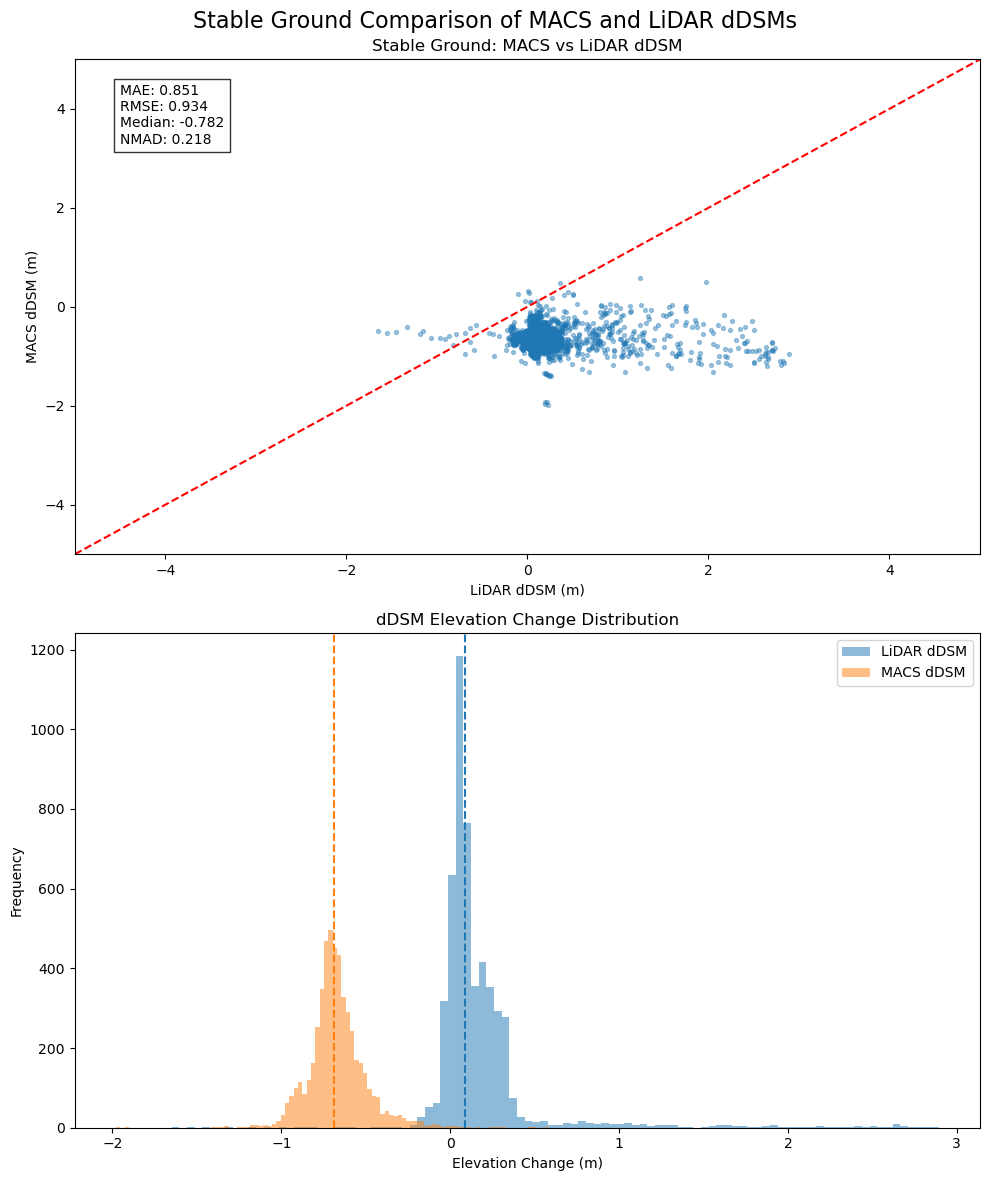

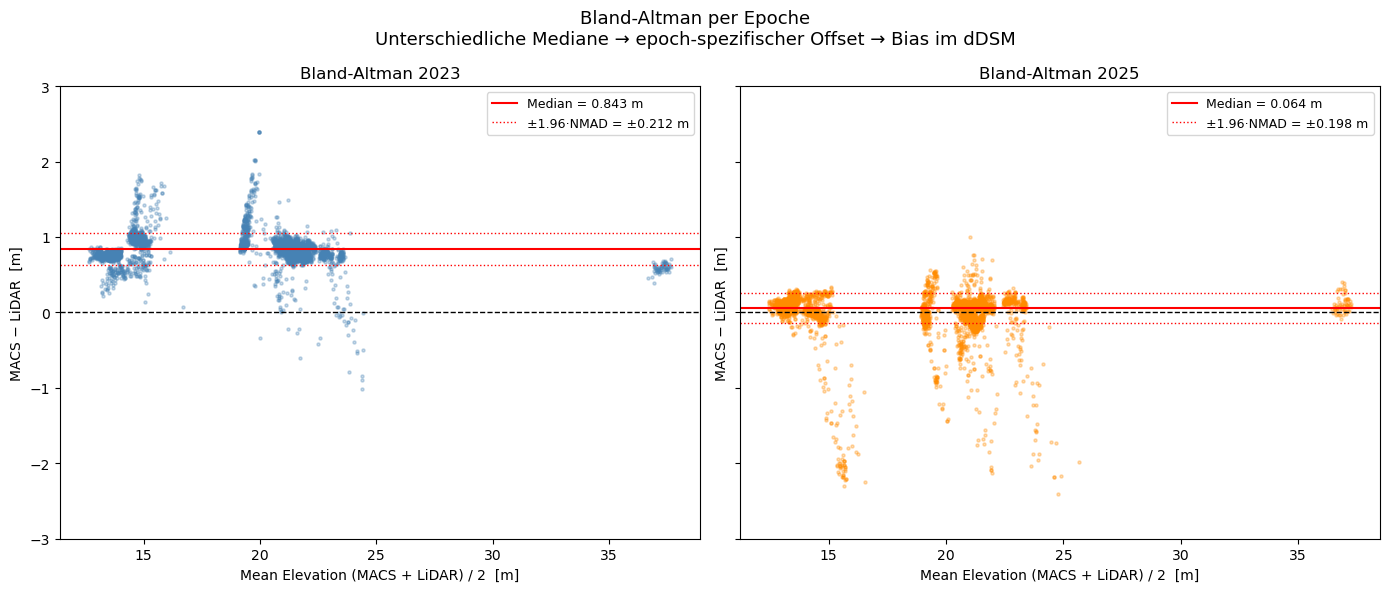

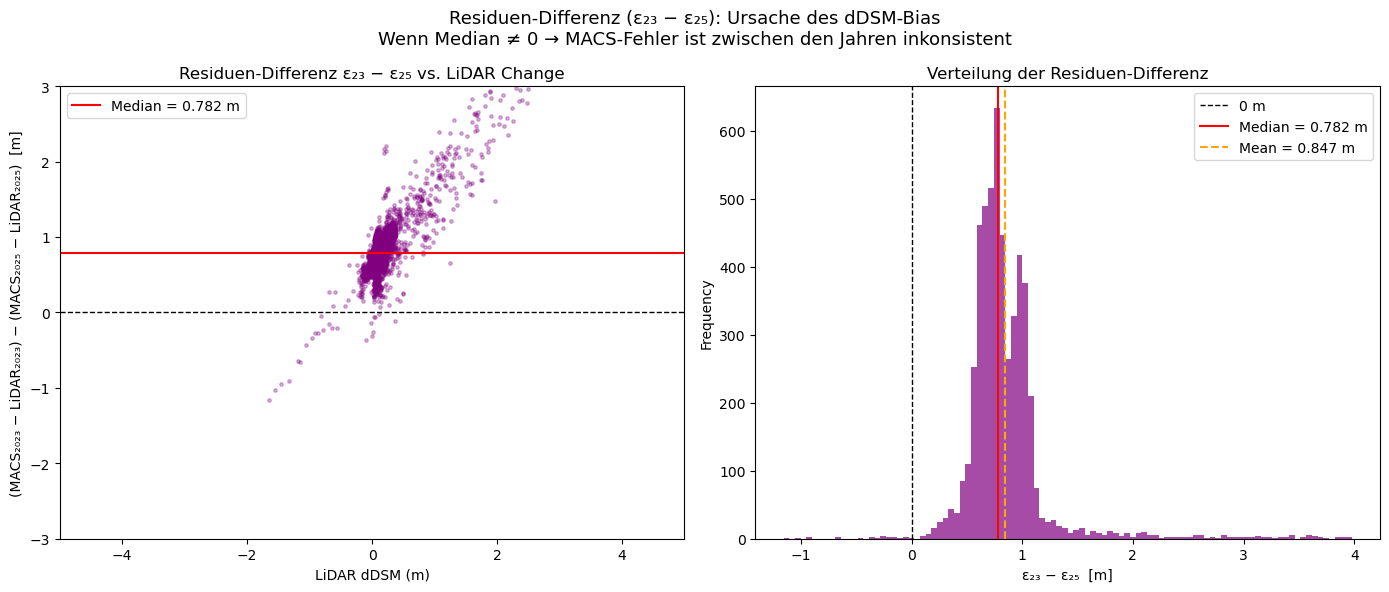

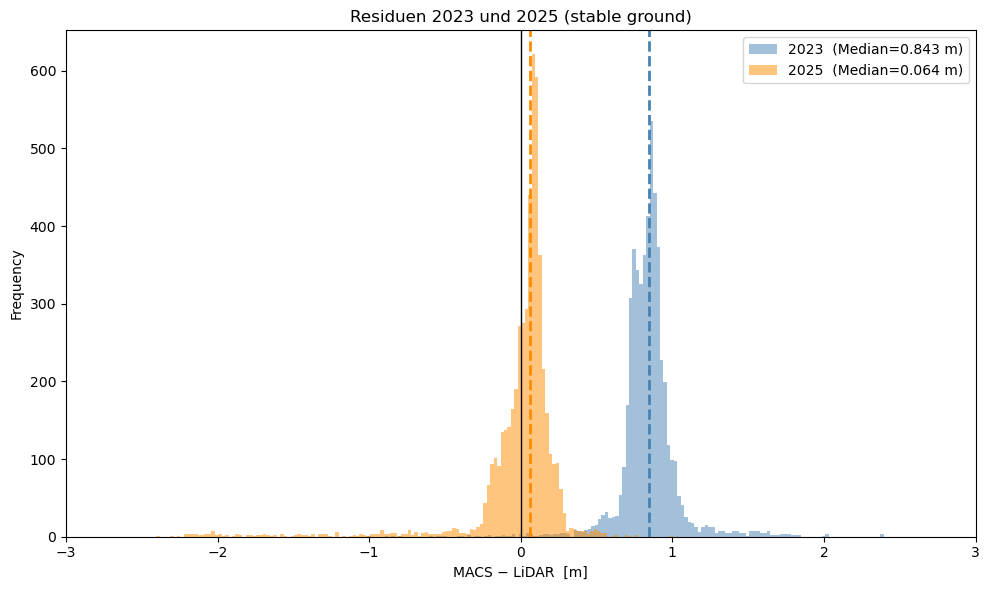


Alle Plots gespeichert.


In [44]:
import numpy as np
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt

from rasterio.warp import reproject, Resampling
from rasterio.features import rasterize

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ============================================================
# FILE PATHS
# ============================================================

macs_2023_path = "/isipd/projects/Response/GIS_RS_projects/Masterarbeit_Till_Weiss/MACS_Ortho_imgs/WC_Inuvik_20230705_15cm_01/Macs_Inuvik_2023_DSM_2m.tif"
lidar_2023_path = "/isipd/projects/p_planetdw/data/lidar/05_results/Perma-X-2023-Till/DSM/Inuvik_DSM_2023_2m.tif"
macs_2025_path  = "/isipd/projects/Response/GIS_RS_projects/Masterarbeit_Till_Weiss/MACS_Ortho_imgs/WC_Inuvik_20250727_15cm_01/Inuvik_2025DSM_2m.tif"
lidar_2025_path = "/isipd/projects/p_planetdw/data/lidar/05_results/Perma-X-2025-Till/DSM/Inuvik_DSM_2025_2m.tif"

stable_ground_gpkg = "/isipd/projects/Response/GIS_RS_projects/Masterarbeit_Till_Weiss/AOI/stable_ground.gpkg"

output_path = "./"

# ============================================================
# FUNCTION: ALIGN TO REFERENCE GRID
# ============================================================

def align_to_reference(src_path, ref_path):
    with rasterio.open(ref_path) as ref:
        ref_data      = ref.read(1)
        ref_transform = ref.transform
        ref_crs       = ref.crs
        ref_shape     = ref_data.shape

    with rasterio.open(src_path) as src:
        aligned = np.empty(ref_shape, dtype=np.float32)
        reproject(
            source=rasterio.band(src, 1),
            destination=aligned,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=Resampling.max
        )

    return aligned, ref_transform, ref_crs

# ============================================================
# ALIGN ALL DSMs TO SAME GRID
# ============================================================

macs_2023, transform, crs = align_to_reference(macs_2023_path, lidar_2023_path)
macs_2025, _, _            = align_to_reference(macs_2025_path, lidar_2023_path)
lidar_2023, _, _           = align_to_reference(lidar_2023_path, lidar_2023_path)
lidar_2025, _, _           = align_to_reference(lidar_2025_path, lidar_2023_path)

# ============================================================
# REMOVE INVALID VALUES
# ============================================================

macs_2023[macs_2023   < -100] = np.nan
macs_2025[macs_2025   < -100] = np.nan
lidar_2023[lidar_2023 < -100] = np.nan
lidar_2025[lidar_2025 < -100] = np.nan

# ============================================================
# LOAD & RASTERIZE STABLE GROUND MASK
# ============================================================

stable_gdf = gpd.read_file(stable_ground_gpkg).to_crs(crs)
stable_gdf["geometry"] = stable_gdf.buffer(2)

stable_mask = rasterize(
    [(geom, 1) for geom in stable_gdf.geometry],
    out_shape=lidar_2023.shape,
    transform=transform,
    fill=0,
    dtype="uint8"
).astype(bool)

# ============================================================
# CREATE dDSMs & EPOCH RESIDUALS
# ============================================================

macs_ddsm  = macs_2025  - macs_2023
lidar_ddsm = lidar_2025 - lidar_2023

# Residual per epoch: how much does MACS deviate from LiDAR?
res_2023 = macs_2023 - lidar_2023   # ε₂₃
res_2025 = macs_2025 - lidar_2025   # ε₂₅

# The term that creates the bias in dDSM:  ε₂₃ − ε₂₅
res_diff = res_2023 - res_2025

# ============================================================
# VALID MASK (stable ground, finite values)
# ============================================================

mask = (
    np.isfinite(macs_ddsm) &
    np.isfinite(lidar_ddsm) &
    np.isfinite(res_2023)  &
    np.isfinite(res_2025)  &
    stable_mask
)

# ============================================================
# EXTRACT STABLE VALUES & FILTER OUTLIERS
# ============================================================

m         = macs_ddsm[mask]
l         = lidar_ddsm[mask]
r23       = res_2023[mask]
r25       = res_2025[mask]
rdiff     = res_diff[mask]
mean_elev = ((macs_2023 + lidar_2023) / 2)[mask]
mean_elev25 = ((macs_2025 + lidar_2025) / 2)[mask]

valid = (np.abs(m) < 5) & (np.abs(l) < 5)
m         = m[valid]
l         = l[valid]
r23       = r23[valid]
r25       = r25[valid]
rdiff     = rdiff[valid]
mean_elev = mean_elev[valid]
mean_elev25 = mean_elev25[valid]

residuals = m - l

# ============================================================
# HELPERS
# ============================================================

def compute_nmad(data):
    return 1.4826 * np.median(np.abs(data - np.median(data)))

# ============================================================
# METRICS
# ============================================================

mae    = mean_absolute_error(l, m)
rmse   = np.sqrt(mean_squared_error(l, m))
r2     = r2_score(l, m)
median = np.median(residuals)
nmad   = compute_nmad(residuals)

print(f"MAE: {mae:.3f}  RMSE: {rmse:.3f}  R²: {r2:.3f}")
print(f"Median bias: {median:.3f}  NMAD: {nmad:.3f}")

# ============================================================
# SAMPLE FOR SCATTER PLOTS
# ============================================================

n   = min(20000, len(m))
idx = np.random.choice(len(m), n, replace=False)

# ============================================================
# FIGURE 1 – ORIGINAL STABLE GROUND PLOT (unchanged)
# ============================================================

fig, axs = plt.subplots(2, 1, figsize=(10, 12))

axs[0].scatter(l[idx], m[idx], s=8, alpha=0.4)
axs[0].plot([-5, 5], [-5, 5], 'r--')
axs[0].set_xlim(-5, 5);  axs[0].set_ylim(-5, 5)
axs[0].set_xlabel("LiDAR dDSM (m)")
axs[0].set_ylabel("MACS dDSM (m)")
axs[0].set_title("Stable Ground: MACS vs LiDAR dDSM")
axs[0].text(0.05, 0.95,
    f"MAE: {mae:.3f}\nRMSE: {rmse:.3f}\nMedian: {median:.3f}\nNMAD: {nmad:.3f}",
    transform=axs[0].transAxes, verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.8))

axs[1].hist(l, bins=100, alpha=0.5, label="LiDAR dDSM")
axs[1].hist(m, bins=100, alpha=0.5, label="MACS dDSM")
axs[1].axvline(np.median(l), linestyle='--', color='C0')
axs[1].axvline(np.median(m), linestyle='--', color='C1')
axs[1].set_title("dDSM Elevation Change Distribution")
axs[1].set_xlabel("Elevation Change (m)")
axs[1].set_ylabel("Frequency")
axs[1].legend()

plt.suptitle("Stable Ground Comparison of MACS and LiDAR dDSMs", fontsize=16)
plt.tight_layout()
plt.savefig(f"{output_path}stable_ground_dDSM_analysis.png", dpi=300)
plt.show()

# ============================================================
# FIGURE 2 – BLAND-ALTMAN PRO EPOCHE
# Zeigt: Ist der Fehler (MACS − LiDAR) zwischen 2023 und 2025
# unterschiedlich? → Erklärt den Bias im Change-Signal.
# ============================================================

fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, r, me, year, color in zip(
    axs,
    [r23, r25],
    [mean_elev, mean_elev25],
    ["2023", "2025"],
    ["steelblue", "darkorange"]
):
    # Subsample for plotting speed
    n_ba = min(10000, len(r))
    idx_ba = np.random.choice(len(r), n_ba, replace=False)

    ax.scatter(me[idx_ba], r[idx_ba], s=5, alpha=0.3, color=color)

    med_r  = np.median(r)
    nmad_r = compute_nmad(r)

    # Median bias line
    ax.axhline(med_r,        color='red',   lw=1.5, label=f"Median = {med_r:.3f} m")
    ax.axhline(0,            color='black', lw=1,   linestyle='--')
    # ±1.96 NMAD agreement limits
    ax.axhline(med_r + 1.96 * nmad_r, color='red', lw=1, linestyle=':', label=f"±1.96·NMAD = ±{1.96*nmad_r:.3f} m")
    ax.axhline(med_r - 1.96 * nmad_r, color='red', lw=1, linestyle=':')

    ax.set_xlabel("Mean Elevation (MACS + LiDAR) / 2  [m]")
    ax.set_ylabel("MACS − LiDAR  [m]")
    ax.set_title(f"Bland-Altman {year}")
    ax.legend(fontsize=9)
    ax.set_ylim(-3, 3)

plt.suptitle(
    "Bland-Altman per Epoche\n"
    "Unterschiedliche Mediane → epoch-spezifischer Offset → Bias im dDSM",
    fontsize=13
)
plt.tight_layout()
plt.savefig(f"{output_path}bland_altman_per_epoch.png", dpi=300)
plt.show()

# ============================================================
# FIGURE 3 – RESIDUEN-DIFFERENZ  (ε₂₃ − ε₂₅)
# Das ist genau der Term, der den Bias im dDSM erzeugt.
# Wenn dieser nicht um 0 zentriert ist → Beweis für inkonsistenten Fehler.
# ============================================================

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Scatter: residual difference vs. LiDAR dDSM
axs[0].scatter(l[idx], rdiff[idx], s=6, alpha=0.3, color='purple')
axs[0].axhline(0,                  color='black', lw=1,   linestyle='--')
axs[0].axhline(np.median(rdiff),   color='red',   lw=1.5, label=f"Median = {np.median(rdiff):.3f} m")
axs[0].set_xlabel("LiDAR dDSM (m)")
axs[0].set_ylabel("(MACS₂₀₂₃ − LiDAR₂₀₂₃) − (MACS₂₀₂₅ − LiDAR₂₀₂₅)  [m]")
axs[0].set_title("Residuen-Differenz ε₂₃ − ε₂₅ vs. LiDAR Change")
axs[0].set_xlim(-5, 5);  axs[0].set_ylim(-3, 3)
axs[0].legend()

# Histogram of residual difference
axs[1].hist(rdiff, bins=100, color='purple', alpha=0.7)
axs[1].axvline(0,                  color='black', lw=1,   linestyle='--', label="0 m")
axs[1].axvline(np.median(rdiff),   color='red',   lw=1.5, label=f"Median = {np.median(rdiff):.3f} m")
axs[1].axvline(np.mean(rdiff),     color='orange',lw=1.5, linestyle='--', label=f"Mean = {np.mean(rdiff):.3f} m")
axs[1].set_xlabel("ε₂₃ − ε₂₅  [m]")
axs[1].set_ylabel("Frequency")
axs[1].set_title("Verteilung der Residuen-Differenz")
axs[1].legend()

plt.suptitle(
    "Residuen-Differenz (ε₂₃ − ε₂₅): Ursache des dDSM-Bias\n"
    "Wenn Median ≠ 0 → MACS-Fehler ist zwischen den Jahren inkonsistent",
    fontsize=13
)
plt.tight_layout()
plt.savefig(f"{output_path}residual_difference_bias.png", dpi=300)
plt.show()

# ============================================================
# FIGURE 4 – EPOCH RESIDUALS ÜBEREINANDERGELEGT
# Direkter visueller Vergleich: ε₂₃ vs. ε₂₅ als Histogramm.
# Wenn die Verteilungen verschoben sind → epoch-spezifischer Offset.
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(r23, bins=150, alpha=0.5, color='steelblue',  label=f"2023  (Median={np.median(r23):.3f} m)")
ax.hist(r25, bins=150, alpha=0.5, color='darkorange', label=f"2025  (Median={np.median(r25):.3f} m)")

ax.axvline(np.median(r23), color='steelblue',  lw=2, linestyle='--')
ax.axvline(np.median(r25), color='darkorange', lw=2, linestyle='--')
ax.axvline(0,              color='black',      lw=1, linestyle='-')

ax.set_xlabel("MACS − LiDAR  [m]")
ax.set_ylabel("Frequency")
ax.set_title(
    "Residuen 2023 und 2025 (stable ground)"
)
ax.legend()
ax.set_xlim(-3, 3)

plt.tight_layout()
plt.savefig(f"{output_path}epoch_residuals_overlay.png", dpi=300)
plt.show()

print("\nAlle Plots gespeichert.")


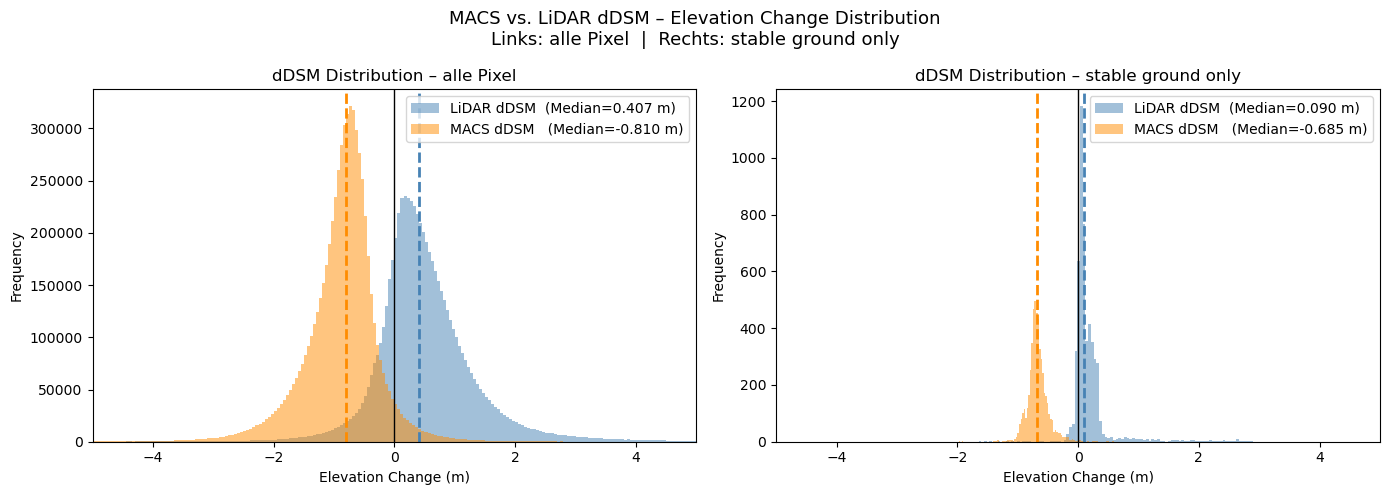

In [38]:
# ============================================================
# DISTRIBUTION PLOT: MACS vs LiDAR dDSM
# Füge das nach dem Berechnen von macs_ddsm & lidar_ddsm ein,
# also nach:
#   macs_ddsm  = macs_2025  - macs_2023
#   lidar_ddsm = lidar_2025 - lidar_2023
# ============================================================

# Valide Pixel (alle, nicht nur stable ground)
mask_all = np.isfinite(macs_ddsm) & np.isfinite(lidar_ddsm)

m_all = macs_ddsm[mask_all]
l_all = lidar_ddsm[mask_all]

# Outlier-Filter
valid_all = (np.abs(m_all) < 5) & (np.abs(l_all) < 5)
m_all = m_all[valid_all]
l_all = l_all[valid_all]

# ============================================================
# PLOT
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Links: Alle Pixel ---
axes[0].hist(l_all, bins=200, alpha=0.5, color='steelblue',
             label=f"LiDAR dDSM  (Median={np.median(l_all):.3f} m)")
axes[0].hist(m_all, bins=200, alpha=0.5, color='darkorange',
             label=f"MACS dDSM   (Median={np.median(m_all):.3f} m)")

axes[0].axvline(np.median(l_all), color='steelblue',  lw=2, linestyle='--')
axes[0].axvline(np.median(m_all), color='darkorange',  lw=2, linestyle='--')
axes[0].axvline(0,                color='black',       lw=1, linestyle='-')

axes[0].set_xlabel("Elevation Change (m)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("dDSM Distribution – alle Pixel")
axes[0].legend()
axes[0].set_xlim(-5, 5)

# --- Rechts: Stable Ground ---
axes[1].hist(l,  bins=100, alpha=0.5, color='steelblue',
             label=f"LiDAR dDSM  (Median={np.median(l):.3f} m)")
axes[1].hist(m,  bins=100, alpha=0.5, color='darkorange',
             label=f"MACS dDSM   (Median={np.median(m):.3f} m)")

axes[1].axvline(np.median(l), color='steelblue',  lw=2, linestyle='--')
axes[1].axvline(np.median(m), color='darkorange',  lw=2, linestyle='--')
axes[1].axvline(0,            color='black',       lw=1, linestyle='-')

axes[1].set_xlabel("Elevation Change (m)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("dDSM Distribution – stable ground only")
axes[1].legend()
axes[1].set_xlim(-5, 5)

plt.suptitle(
    "MACS vs. LiDAR dDSM – Elevation Change Distribution\n"
    "Links: alle Pixel  |  Rechts: stable ground only",
    fontsize=13
)
plt.tight_layout()
plt.savefig(f"{output_path}ddsm_distribution.png", dpi=300)
plt.show()

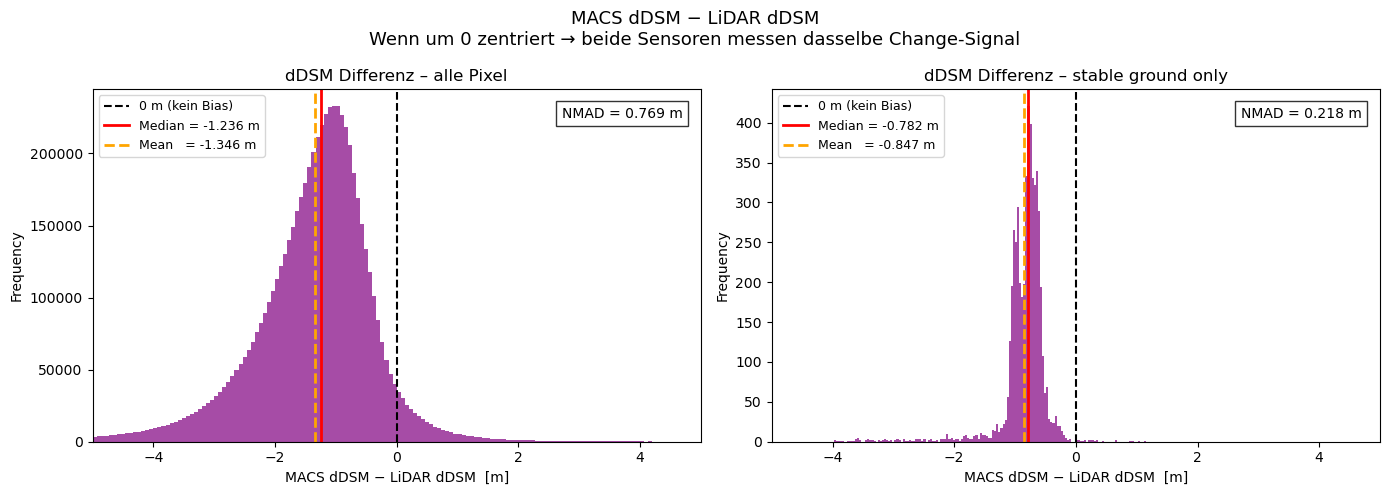

In [41]:
# ============================================================
# DISTRIBUTION PLOT: (MACS dDSM) - (LiDAR dDSM)
# Direkte Abweichung des MACS Change-Signals vom LiDAR Change-Signal
# ============================================================

diff_ddsm = macs_ddsm - lidar_ddsm

# Valide Pixel
mask_all  = np.isfinite(diff_ddsm)
diff_all  = diff_ddsm[mask_all]
diff_all  = diff_all[np.abs(diff_all) < 5]

# --- Stable ground ---
# mask ist 2D (Raster), damit direkt indexieren
mask_stable = (
    np.isfinite(macs_ddsm) &
    np.isfinite(lidar_ddsm) &
    stable_mask
)
diff_stable = diff_ddsm[mask_stable]
diff_stable = diff_stable[np.abs(diff_stable) < 5]

# ============================================================
# PLOT
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title in zip(
    axes,
    [diff_all, diff_stable],
    ["alle Pixel", "stable ground only"]
):
    med  = np.median(data)
    mean = np.mean(data)
    nmad = compute_nmad(data)

    ax.hist(data, bins=150, color='purple', alpha=0.7)
    ax.axvline(0,    color='black',  lw=1.5, linestyle='--', label="0 m (kein Bias)")
    ax.axvline(med,  color='red',    lw=2,   label=f"Median = {med:.3f} m")
    ax.axvline(mean, color='orange', lw=2,   linestyle='--', label=f"Mean   = {mean:.3f} m")

    ax.set_xlabel("MACS dDSM − LiDAR dDSM  [m]")
    ax.set_ylabel("Frequency")
    ax.set_title(f"dDSM Differenz – {title}")
    ax.legend(fontsize=9)
    ax.set_xlim(-5, 5)

    ax.text(0.97, 0.95,
        f"NMAD = {nmad:.3f} m",
        transform=ax.transAxes,
        ha='right', va='top',
        bbox=dict(facecolor='white', alpha=0.8))

plt.suptitle(
    "MACS dDSM − LiDAR dDSM\n"
    "Wenn um 0 zentriert → beide Sensoren messen dasselbe Change-Signal",
    fontsize=13
)
plt.tight_layout()
plt.savefig(f"{output_path}ddsm_difference_distribution.png", dpi=300)
plt.show()
